# Shea Homes Customer Review Analysis
### Customer Insights with Sentiment Analysis
---

**Data Source:** https://www.newhomesource.com/builder/shea-homes/reviews/612/

**Dataset**: 2,039 verified homebuyer reviews (Sept 2020 - March 2026)

**Author**: Griffin Snider

## What This Report Does

This report uses nlp tools to read and analyze every Shea Homes customer review.

Specifically:

This project analyzes 2,039 customer reviews of Shea Homes collected from NewHomeSource.com. NewHomeSource is a review platform where verified homebuyers rate their builder after closing. Each review includes an overall star rating (1-5) plus four sub-ratings: Quality, Trustworthiness, Value, and Responsiveness. Buyers also write open-ended comments describing their experience. This dataset contains reviews for Shea Homes collected between September 2020 and March 2026, covering 11 markets across Arizona, California, Colorado, Nevada, North Carolina, Texas, Washington, and more.

Reading 2,039 reviews manually would take weeks. Even then, it would be hard to spot patterns consistently, like which markets are struggling, what topics keep coming up in negative reviews, or which customers might be at risk of leaving bad word-of-mouth. This project automates that work using a multi-method Natural Language Processing (NLP) framework.

The pipeline includes: \
(1) sentiment classification using VADER (Valence Aware Dictionary and sEntiment Reasoner), a rule-based model tuned for customer review text \
(2) topic extraction using TF-IDF (Term Frequency-Inverse Document Frequency) vectorization and LDA (Latent Dirichlet Allocation), which surface recurring themes without predefined categories \
(3) predictive modeling using machine learning classifiers to flag at-risk reviews \
(4) contextual analysis using a locally-deployed large language model (LLaMA 3.2 via Ollama) that reads individual reviews and generates recommendations

---
## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
from scipy import stats
import re
import warnings
warnings.filterwarnings("ignore")

# nlp tools
import nltk
nltk.download("vader_lexicon", quiet=True)
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("stopwords", quiet=True)
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from textblob import TextBlob
from wordcloud import WordCloud

#ml
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.pipeline import Pipeline

# visual style
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
SHEA_BLUE = "#1a5276"
SHEA_GOLD = "#d4a843"
SHEA_PALETTE = ["#c0392b", "#e67e22", "#f1c40f", "#27ae60", "#1a5276"]

In [2]:
# load the dataset
df = pd.read_csv("shea_homes_reviews.csv", encoding="utf-8-sig")
df["date"] = pd.to_datetime(df["date"], errors="coerce")

print(f"{len(df):,} reviews")
print(f"Date range: {df['date'].min().strftime('%B %Y')} to {df['date'].max().strftime('%B %Y')}")
df.head(3)

2,039 reviews
Date range: September 2020 to March 2026


,title,reviewer_name,verified_homebuyer,date,location,review_text,total_score,quality,trustworthiness,value,responsiveness
0,Matt was excellent,Bruce M.,Yes,2026-02-23,"San Tan Valley, AZ",Excellent service from everyone on team,5,5,5,5,5
1,Review,Lillian B.,Yes,2026-02-17,"Livermore, CA","Great for all; buying experience, working with...",5,5,5,5,5
2,Steve,Steve K.,Yes,2026-02-09,"Las Vegas, NV",It was such a great process from initial depos...,5,5,5,5,5


---
# Part 1: Summary Statistics

Before applying modeling or artificial intelligence methods, the analysis begins with summary statistics. This step looks at the basic structure of the dataset, including the total number of reviews, how ratings are distributed across the 1–5 star scale, which states and cities generate the most feedback, and the typical length of customer reviews. Establishing these baseline patterns provides context for the more advanced analyses that follow.

## 1.1 Overview

In [3]:
# text metrics
# tokens
df["word_count"] = df["review_text"].apply(lambda x: len(str(x).split()))
df["char_count"] = df["review_text"].apply(lambda x: len(str(x)))

# build a vocabulary
all_words = " ".join(df["review_text"].astype(str)).lower().split()
all_words_clean = [re.sub(r"[^a-z']", "", w) for w in all_words]
all_words_clean = [w for w in all_words_clean if w]
vocab = set(all_words_clean)

# geography
df["state"] = df["location"].str.extract(r",\s*([A-Z]{2})$")
df["year"] = df["date"].dt.year

# display the overview
print("=" * 55)
print("              SHEA HOMES REVIEW DATASET          ")
print("=" * 55)
print(f"  Total reviews:              {len(df):>8,}")
print(f"  Total Tokens:               {sum(df['word_count']):>8,}")
print(f"  Unique words:               {len(vocab):>8,}")
print(f"  Average review length:      {df['word_count'].mean():>8.1f} words")
print(f"  Median review length:       {df['word_count'].median():>8.0f} words")
print(f"  Shortest review:            {df['word_count'].min():>8} words")
print(f"  Longest review:             {df['word_count'].max():>8} words")
print(f"  Unique cities:              {df['location'].nunique():>8}")
print(f"  States covered:             {df['state'].nunique():>8}")
print("=" * 55)

              SHEA HOMES REVIEW DATASET          
  Total reviews:                 2,039
  Total Tokens:                117,979
  Unique words:                  7,049
  Average review length:          57.9 words
  Median review length:             34 words
  Shortest review:                   2 words
  Longest review:                 1092 words
  Unique cities:                    74
  States covered:                   11


The dataset contains 2,039 reviews, totaling 117,979 words. Reviews average 57.9 words, but the median is just 34 words, meaning most are brief while a smaller number contain detailed feedback. The reviews span 74 cities across 11 states. Length ranges from 2 words to 1,092 words, capturing everything from quick ratings to detailed accounts of the homebuying experience.


## 1.2 Star Rating Distribution

This section shows how customers rated their experience on a 1 to 5 star scale. The left chart counts how many reviews fell at each star level. The right chart shows the average score across five different rating categories that customers fill out: Overall, Quality, Trustworthiness, Value, and Responsiveness.

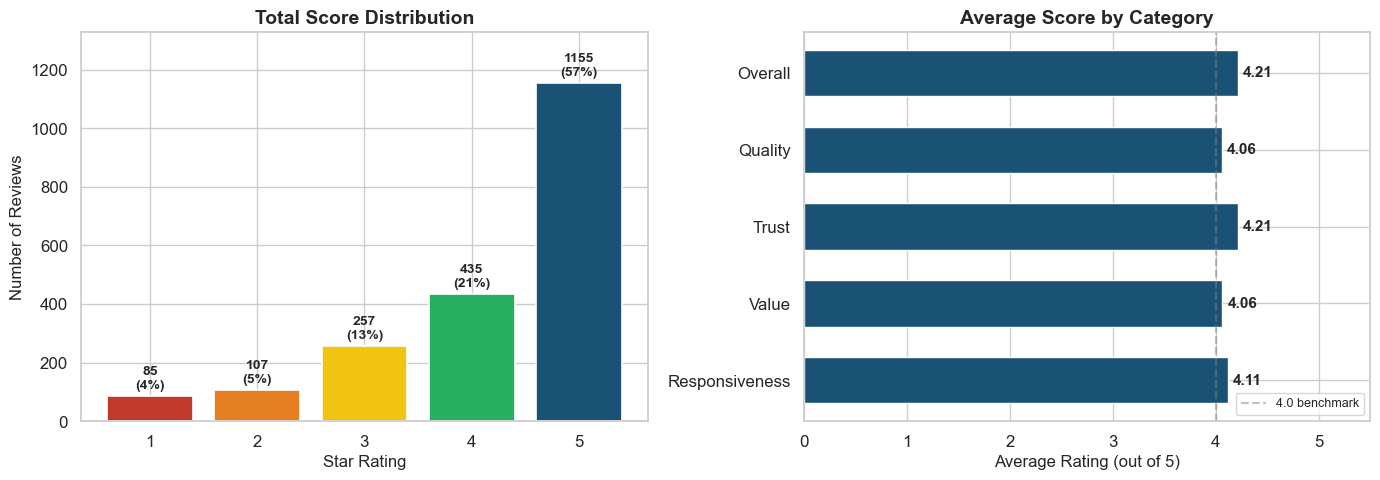

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# left: Total score distribution
score_counts = df["total_score"].value_counts().sort_index()
bars = axes[0].bar(score_counts.index, score_counts.values, color=SHEA_PALETTE, edgecolor="white", linewidth=1.2)

axes[0].set_ylim(0, score_counts.max() * 1.15)

for bar, val in zip(bars, score_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
                 f"{val}\n({val/len(df):.0%})", ha="center", va="bottom", fontsize=10, fontweight="bold")
axes[0].set_xlabel("Star Rating", fontsize=12)
axes[0].set_ylabel("Number of Reviews", fontsize=12)
axes[0].set_title("Total Score Distribution", fontsize=14, fontweight="bold")
axes[0].set_xticks([1, 2, 3, 4, 5])
axes[0].set_xticklabels(["1", "2", "3", "4", "5"])

# Right: Average by category
categories = ["total_score", "quality", "trustworthiness", "value", "responsiveness"]
cat_labels = ["Overall", "Quality", "Trust", "Value", "Responsiveness"]
cat_means = [df[c].mean() for c in categories]

bars2 = axes[1].barh(cat_labels[::-1], cat_means[::-1], color=SHEA_BLUE, edgecolor="white", height=0.6)
for bar, val in zip(bars2, cat_means[::-1]):
    axes[1].text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
                 f"{val:.2f}", ha="left", va="center", fontsize=11, fontweight="bold")
axes[1].set_xlim(0, 5.5)
axes[1].set_xlabel("Average Rating (out of 5)", fontsize=12)
axes[1].set_title("Average Score by Category", fontsize=14, fontweight="bold")
axes[1].axvline(x=4.0, color="gray", linestyle="--", alpha=0.5, label="4.0 benchmark")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig("rating_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

The distribution is heavily skewed with 5-star reviews making up 57%, while 1-star reviews account for only 4%. All five categories average above 4.0, with Trust scoring highest (4.21) and Quality and Value slightly lower (4.06). Value perceptions, specifically how customers weigh cost against what was delivered, may represent an area worth watching.

## 1.3 Review Volume Over Time

This chart tracks review activity and customer satisfaction over time. The blue bars show the number of reviews submitted each month, representing review volume. The gold line shows the three-month rolling average star rating, which smooths short-term fluctuations to highlight broader trends in customer satisfaction.


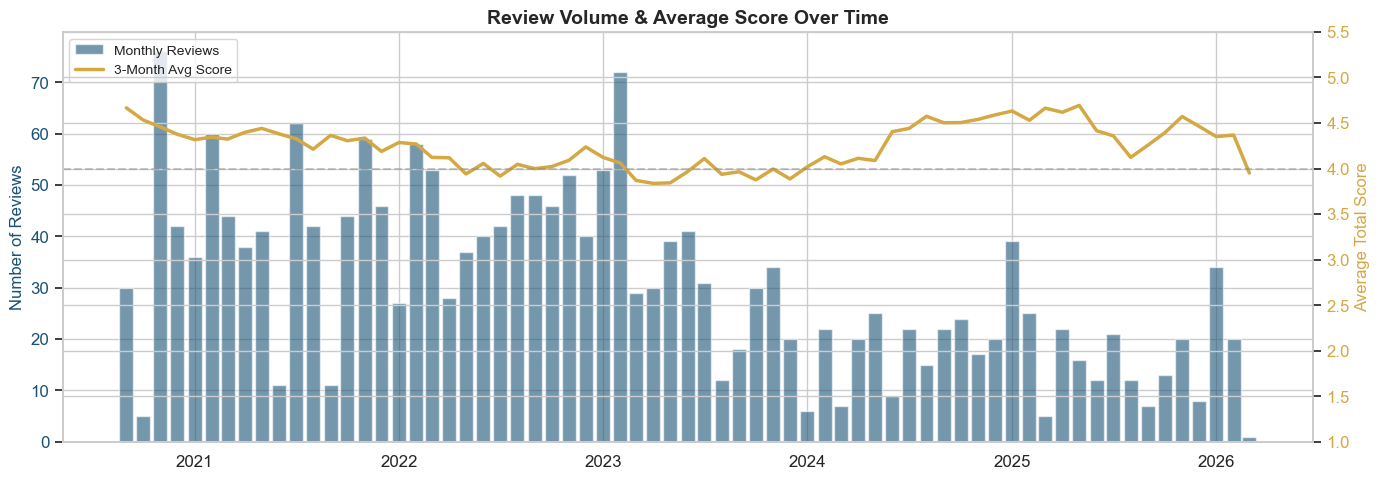

In [5]:
# monthly review volume and rolling average score
df["year_month"] = df["date"].dt.to_period("M")
monthly = df.groupby("year_month").agg(
    review_count=("total_score", "count"),
    avg_score=("total_score", "mean")
).reset_index()
monthly["year_month"] = monthly["year_month"].dt.to_timestamp()

fig, ax1 = plt.subplots(figsize=(14, 5))

# bar chart for volume
ax1.bar(monthly["year_month"], monthly["review_count"], width=25, color=SHEA_BLUE, alpha=0.6, label="Monthly Reviews")
ax1.set_ylabel("Number of Reviews", fontsize=12, color=SHEA_BLUE)
ax1.set_xlabel("")
ax1.tick_params(axis="y", labelcolor=SHEA_BLUE)

# line chart for average score
ax2 = ax1.twinx()
ax2.plot(monthly["year_month"], monthly["avg_score"].rolling(3, min_periods=1).mean(),
         color=SHEA_GOLD, linewidth=2.5, marker="", label="3-Month Avg Score")
ax2.set_ylabel("Average Total Score", fontsize=12, color=SHEA_GOLD)
ax2.set_ylim(1, 5.5)
ax2.tick_params(axis="y", labelcolor=SHEA_GOLD)
ax2.axhline(y=4.0, color="gray", linestyle="--", alpha=0.4)

# combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=10)

plt.title("Review Volume & Average Score Over Time", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("reviews_over_time.png", dpi=150, bbox_inches="tight")
plt.show()

Review volume was highest during 2021–2022, when homebuilding activity was higher following the post-pandemic housing surge. Monthly review counts decline after this period as market activity slowed. Despite fluctuations in volume, the three-month average rating remains consistently above 4.0, showing stable customer satisfaction over time. A small dip appears in late 2025, which may warrant closer examination at the market or community level.


## 1.4 Geographic Breakdown

These charts examine the geographic distribution of customer feedback. The left chart shows the number of reviews submitted from each state, showing where the largest share of customer feedback originates. The right chart shows the average star rating by state, calculated only for states with at least 10 reviews.

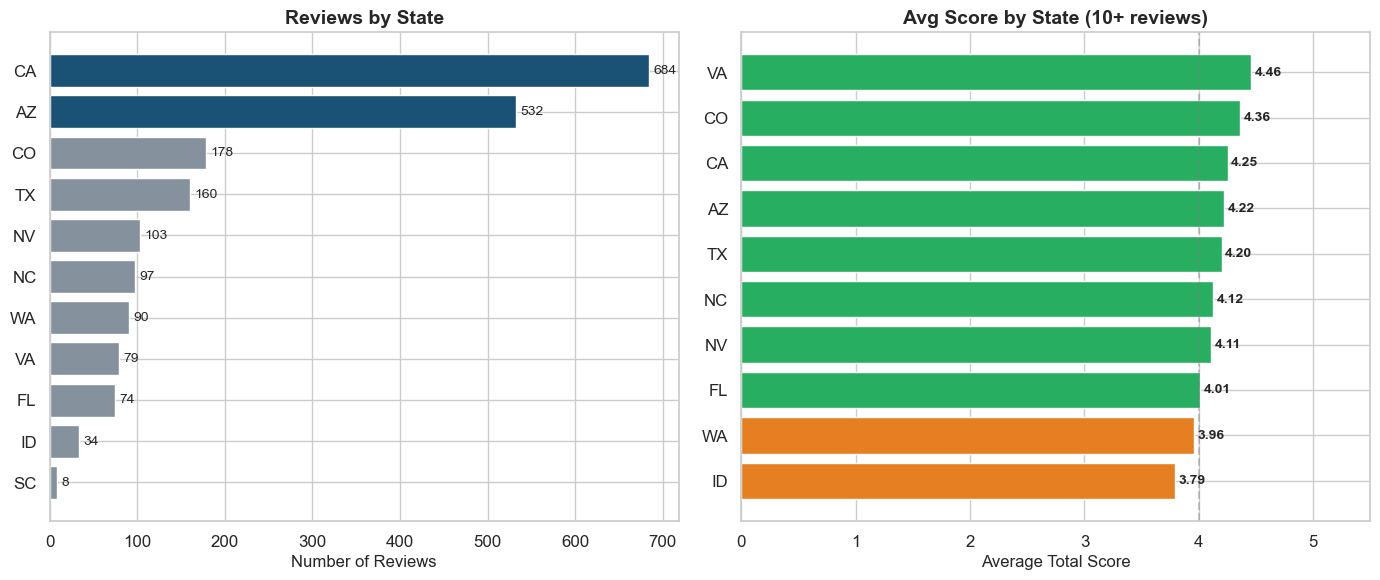

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Left: Reviews by state ---
state_counts = df["state"].value_counts()
colors = [SHEA_BLUE if s in ["CA", "AZ"] else "#85929e" for s in state_counts.index]
bars = axes[0].barh(state_counts.index[::-1], state_counts.values[::-1],
                     color=colors[::-1], edgecolor="white")
for bar, val in zip(bars, state_counts.values[::-1]):
    axes[0].text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
                 str(val), ha="left", va="center", fontsize=10)
axes[0].set_xlabel("Number of Reviews", fontsize=12)
axes[0].set_title("Reviews by State", fontsize=14, fontweight="bold")

# --- Right: Avg score by state ---
state_scores = df.groupby("state")["total_score"].agg(["mean", "count"]).sort_values("mean", ascending=True)
state_scores = state_scores[state_scores["count"] >= 10]  # only states with 10+ reviews
bar_colors = ["#27ae60" if m >= 4.0 else "#e67e22" if m >= 3.0 else "#c0392b" for m in state_scores["mean"]]
bars2 = axes[1].barh(state_scores.index, state_scores["mean"], color=bar_colors, edgecolor="white")
for bar, val in zip(bars2, state_scores["mean"]):
    axes[1].text(bar.get_width() + 0.03, bar.get_y() + bar.get_height()/2,
                 f"{val:.2f}", ha="left", va="center", fontsize=10, fontweight="bold")
axes[1].set_xlim(0, 5.5)
axes[1].set_xlabel("Average Total Score", fontsize=12)
axes[1].set_title("Avg Score by State (10+ reviews)", fontsize=14, fontweight="bold")
axes[1].axvline(x=4.0, color="gray", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("geographic_breakdown.png", dpi=150, bbox_inches="tight")
plt.show()

Most reviews originate from California (684) and Arizona (532), which together account for roughly 60% of the dataset. These states represent the largest share of Shea Homes customer feedback on NewHomeSource. Average ratings across most states remain above 4.0, indicating generally strong satisfaction across markets. A few states show slightly lower averages, which may reflect differences in local operations, project timelines, or customer expectations. States with very small sample sizes (South Carolina) are excluded from the average score comparison to avoid misleading results.


## 1.5 Top Cities & Review Length Analysis

This chart identifies the cities that generate the largest volume of customer reviews. Each bar represents the number of reviews submitted from a specific city.


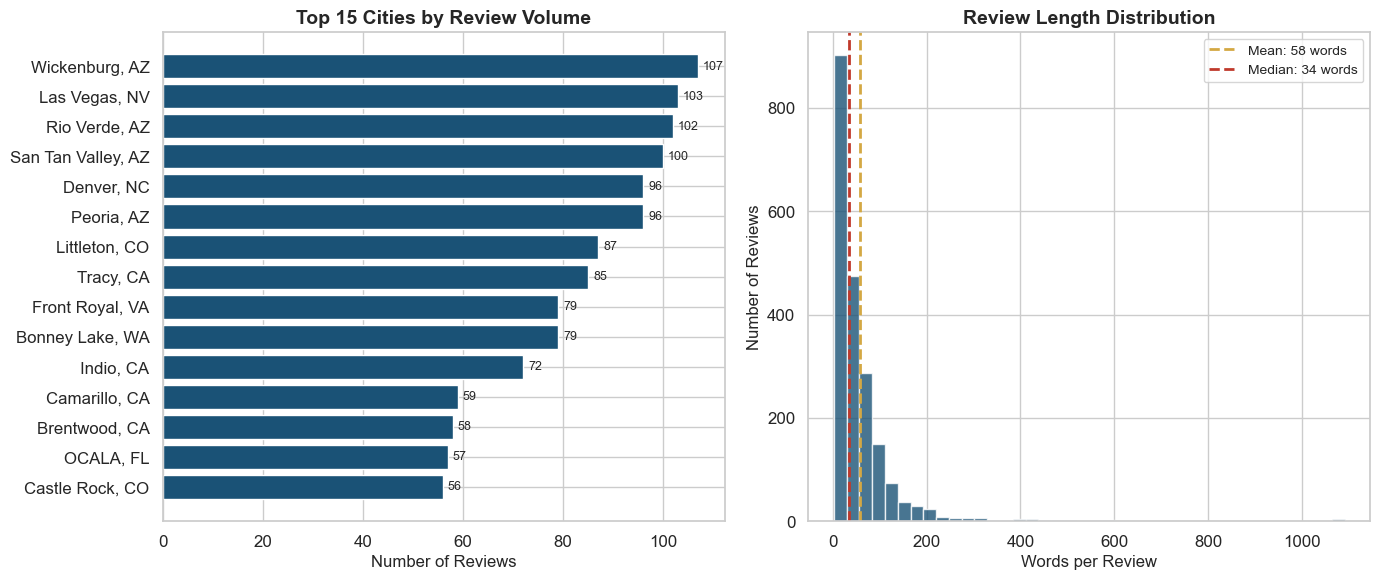

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Left: Top 15 cities ---
top_cities = df["location"].value_counts().head(15)
axes[0].barh(top_cities.index[::-1], top_cities.values[::-1], color=SHEA_BLUE, edgecolor="white")
for i, (val, city) in enumerate(zip(top_cities.values[::-1], top_cities.index[::-1])):
    axes[0].text(val + 1, i, str(val), ha="left", va="center", fontsize=9)
axes[0].set_xlabel("Number of Reviews", fontsize=12)
axes[0].set_title("Top 15 Cities by Review Volume", fontsize=14, fontweight="bold")

# --- Right: Review length distribution ---
axes[1].hist(df["word_count"], bins=40, color=SHEA_BLUE, edgecolor="white", alpha=0.8)
axes[1].axvline(df["word_count"].mean(), color=SHEA_GOLD, linewidth=2, linestyle="--",
                label=f"Mean: {df['word_count'].mean():.0f} words")
axes[1].axvline(df["word_count"].median(), color="#c0392b", linewidth=2, linestyle="--",
                label=f"Median: {df['word_count'].median():.0f} words")
axes[1].set_xlabel("Words per Review", fontsize=12)
axes[1].set_ylabel("Number of Reviews", fontsize=12)
axes[1].set_title("Review Length Distribution", fontsize=14, fontweight="bold")
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.savefig("cities_and_length.png", dpi=150, bbox_inches="tight")
plt.show()

Customer feedback is concentrated in a small number of communities. Cities such as Wickenburg, AZ; Las Vegas, NV; Rio Verde, AZ; and San Tan Valley, AZ contribute the highest number of reviews. These locations represent the areas where the dataset contains the most direct customer experience information.

## 1.6 Rating Correlations

This heatmap shows the correlation between the five rating categories: Overall, Quality, Trust, Value, and Responsiveness. Correlation measures how closely two variables move together. Values closer to 1.0 indicate a strong relationship, meaning customers tend to rate those categories similarly.

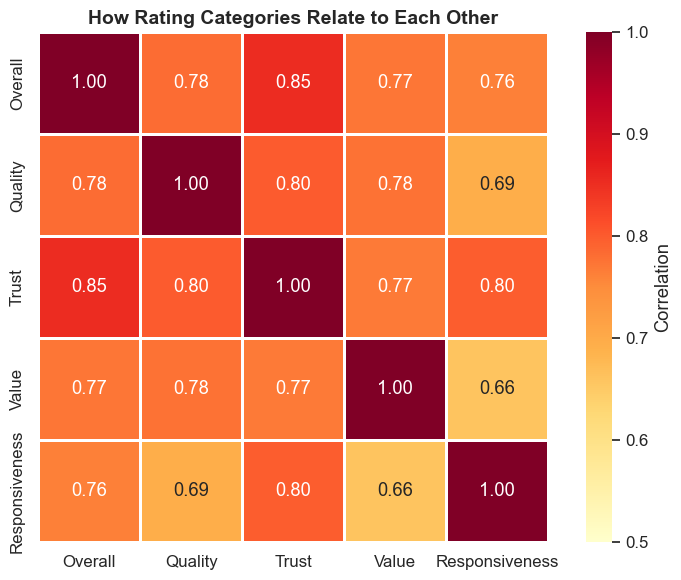

In [8]:
score_cols = ["total_score", "quality", "trustworthiness", "value", "responsiveness"]
score_labels = ["Overall", "Quality", "Trust", "Value", "Responsiveness"]
corr = df[score_cols].corr()
corr.index = score_labels
corr.columns = score_labels

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="YlOrRd", vmin=0.5, vmax=1,
            square=True, linewidths=1, ax=ax, cbar_kws={"label": "Correlation"})
ax.set_title("How Rating Categories Relate to Each Other", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

All categories are highly correlated, showing that customers who rate one dimension poorly tend to rate everything poorly. This suggests the overall experience is somewhat holistic: a bad construction experience drags down trust, value, and responsiveness perceptions too.


---
# Part 2: Data Evaluation

Before conducting analysis, the dataset must first be evaluated for quality, representativeness, and potential limitations. Key considerations include whether 2,039 reviews constitute an adequate sample size, and whether any biases or gaps in coverage may affect the findings. This section provides a transparent assessment of the dataset's strengths and limitations prior to deriving recommendations.

## 2.1 Suitability for Business Questions

Core business question: What do customer reviews show about the Shea Homes homebuying experience, and which aspects of that experience represent the largest opportunity for improvement?


This dataset is well-suited to answer this because:
- Every review is from a verified homebuyer, meaning this is real customer feedback
- Reviews contain free-text responses in addition to star ratings
- Five separate rating dimensions (Quality, Trustworthiness, Value, Responsiveness) let us pinpoint which aspect of the experience is driving satisfaction or dissatisfaction
- Geographic and temporal data let us track performance across markets and over time

## 2.2 Sample Size Assessment

This section evaluates whether the dataset is large enough to support reliable conclusions. It summarizes the total number of reviews, the average rating, and how reviews are distributed across states.

In [9]:
n = len(df)
mean_score = df["total_score"].mean()
std_score = df["total_score"].std()

# 95% confidence interval for the mean
margin_of_error = 1.96 * (std_score / np.sqrt(n))
ci_low = mean_score - margin_of_error
ci_high = mean_score + margin_of_error

print("SAMPLE SIZE")
print("=" * 50)
print(f"  Sample size:              {n:,} reviews")
print(f"  Mean total score:         {mean_score:.3f}")
print(f"  Standard deviation:       {std_score:.3f}")
print(f"  95% Confidence Interval:  [{ci_low:.3f}, {ci_high:.3f}]")
print(f"  Margin of error:          ±{margin_of_error:.3f} stars")
print()

# per-state sample sizes
print(f"\n  Per-state sample sizes:")
for state, count in df["state"].value_counts().items():
    print(f"    {state}: {count:>4} reviews")

SAMPLE SIZE
  Sample size:              2,039 reviews
  Mean total score:         4.210
  Standard deviation:       1.111
  95% Confidence Interval:  [4.162, 4.259]
  Margin of error:          ±0.048 stars


  Per-state sample sizes:
    CA:  684 reviews
    AZ:  532 reviews
    CO:  178 reviews
    TX:  160 reviews
    NV:  103 reviews
    NC:   97 reviews
    WA:   90 reviews
    VA:   79 reviews
    FL:   74 reviews
    ID:   34 reviews
    SC:    8 reviews


The dataset contains 2,039 reviews with an average rating of 4.21. To estimate how precise this average is, we calculate a 95% confidence interval, which represents the range where the true average customer rating is likely to fall. The interval of 4.162 to 4.259 indicates that the estimated average rating is statistically stable. Review counts vary across states. Arizona and California account for the largest share of feedback, while several states have smaller samples. Locations with fewer reviews provide less statistical certainty and should be interpreted cautiously.


## 2.3 Potential Biases

Online review datasets often contain structural biases that can influence how results should be interpreted. This section identifies several common sources of bias within the dataset and explains how they may affect the conclusions drawn from the analysis.


Here are the biases we should keep in mind:

| Bias | Description | Impact |
|------|-------------|--------|
| **Self-selection bias** | Customers with strong opinions (very happy or very unhappy) are more likely to leave a review. Customers with "just okay" experiences may not bother. | May overrepresent extreme opinions |
| **Geographic concentration** | CA and AZ account for ~60% of reviews. Insights may not generalize equally to smaller markets like ID or SC. | State-level conclusions should note sample sizes |
| **Temporal skew** | 2021–2022 had peak review volume (post-COVID housing boom). Recent years have fewer reviews. | Trends may reflect market conditions, not just Shea's performance |
| **Platform bias** | TrustBuilder® is a builder-partnered review platform. Reviews may skew more positive compared to an independent site like Yelp or BBB. | Overall sentiment may be inflated |

The most significant is platform bias. Because the reviews originate from a builder-partnered platform, overall ratings may skew more positive than reviews found on independent consumer sites. As a result, the negative reviews that do appear in the dataset are particularly informative. They represent customers whose dissatisfaction was strong enough to be expressed despite the generally positive environment of the platform.


---
# Part 3: Preliminary Sentiment Analysis

Sentiment analysis is a natural language processing technique that allows an algorithm to evaluate written feedback and estimate the emotional tone of the text. Instead of manually reading thousands of reviews, algorithms analyze the words used in each comment to determine whether the overall message is positive, negative, or neutral. Words associated with positive experiences (such as “great” or “helpful”) increase the sentiment score, while words associated with problems or frustration decrease it.

Each review is converted into a numerical sentiment score ranging from −1 to +1, where −1 represents very negative language and +1 represents very positive language. To increase reliability, this analysis uses two widely used sentiment models. VADER (Valence Aware Dictionary and sEntiment Reasoner) is designed specifically for social media and review text and accounts for emphasis such as capitalization, punctuation, and emotional wording. TextBlob is a general-purpose language model that evaluates sentiment based on the balance of positive and negative terms within the text. Using two independent methods allows the analysis to compare results and confirm that the patterns observed in customer sentiment are consistent.


## 3.1 Running Sentiment Analysis

In [10]:
# VADER 
# VADER gives each review a "compound" score from -1 (most negative) to +1 (most positive)
sia = SentimentIntensityAnalyzer()

def get_vader_scores(text):
    scores = sia.polarity_scores(str(text))
    return scores["compound"], scores["pos"], scores["neg"], scores["neu"]

vader_results = df["review_text"].apply(get_vader_scores)
df["vader_compound"] = vader_results.apply(lambda x: x[0])
df["vader_pos"] = vader_results.apply(lambda x: x[1])
df["vader_neg"] = vader_results.apply(lambda x: x[2])
df["vader_neu"] = vader_results.apply(lambda x: x[3])

# classify: compound >= 0.05 = positive, <= -0.05 = negative, else neutral
df["vader_label"] = df["vader_compound"].apply(
    lambda x: "Positive" if x >= 0.05 else ("Negative" if x <= -0.05 else "Neutral")
)

# textblob
# textblob gives polarity (-1 to +1) and subjectivity (0 = fact, 1 = opinion)
df["textblob_polarity"] = df["review_text"].apply(lambda x: TextBlob(str(x)).sentiment.polarity)
df["textblob_subjectivity"] = df["review_text"].apply(lambda x: TextBlob(str(x)).sentiment.subjectivity)

df["textblob_label"] = df["textblob_polarity"].apply(
    lambda x: "Positive" if x > 0.05 else ("Negative" if x < -0.05 else "Neutral")
)

print("=== VADER Results ===")
print(df["vader_label"].value_counts().to_string())
print("\n=== TextBlob Results ===")
print(df["textblob_label"].value_counts().to_string())

=== VADER Results ===
vader_label
Positive    1598
Negative     328
Neutral      113

=== TextBlob Results ===
textblob_label
Positive    1639
Neutral      235
Negative     165


## 3.2 Overall Sentiment Breakdown
These charts summarize how each sentiment model classified the reviews. The pie charts show the percentage of reviews labeled positive, neutral, or negative by each tool. The chart on the right compares the average sentiment score with the star rating to verify that the models behave as expected. If the models are working correctly, reviews with higher star ratings should also show more positive sentiment

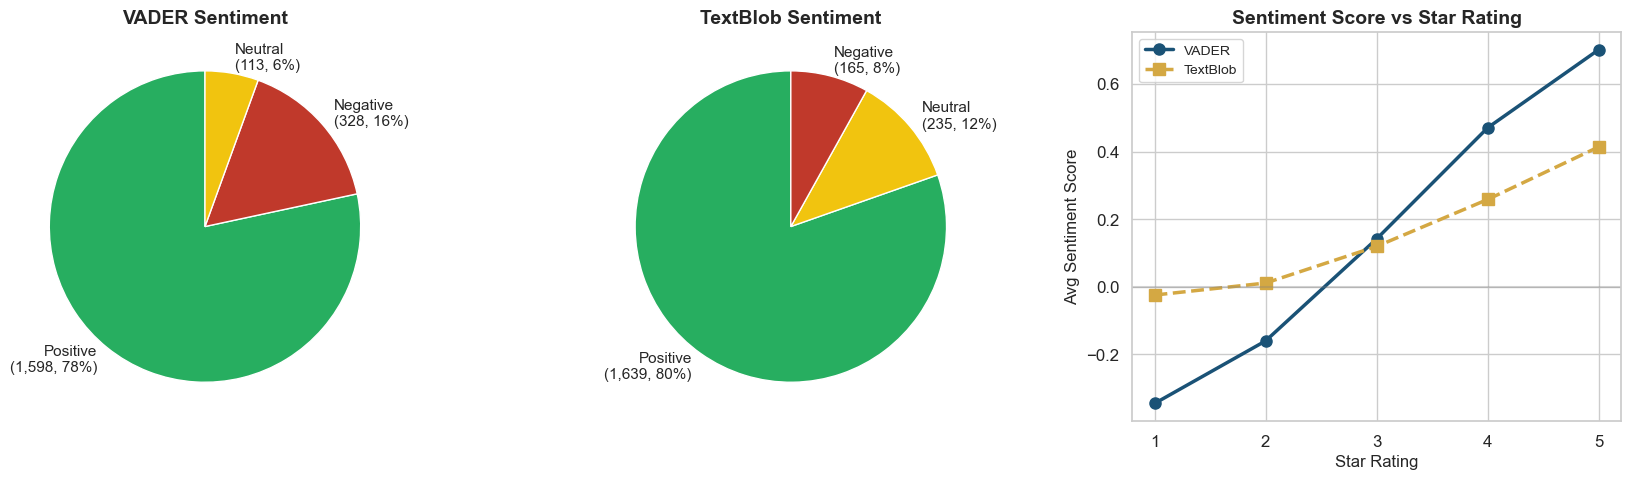

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
sent_colors = {"Positive": "#27ae60", "Neutral": "#f1c40f", "Negative": "#c0392b"}

# VADER pie
vader_counts = df["vader_label"].value_counts()
axes[0].pie(vader_counts, labels=[f"{l}\n({v:,}, {v/len(df):.0%})" for l, v in vader_counts.items()],
            colors=[sent_colors[l] for l in vader_counts.index],
            startangle=90, textprops={"fontsize": 11})
axes[0].set_title("VADER Sentiment", fontsize=14, fontweight="bold")

# TextBlob pie
tb_counts = df["textblob_label"].value_counts()
axes[1].pie(tb_counts, labels=[f"{l}\n({v:,}, {v/len(df):.0%})" for l, v in tb_counts.items()],
            colors=[sent_colors[l] for l in tb_counts.index],
            startangle=90, textprops={"fontsize": 11})
axes[1].set_title("TextBlob Sentiment", fontsize=14, fontweight="bold")

# Sentiment score by star rating 
star_sentiment = df.groupby("total_score")[["vader_compound", "textblob_polarity"]].mean()
x = star_sentiment.index
axes[2].plot(x, star_sentiment["vader_compound"], "o-", color=SHEA_BLUE, linewidth=2.5,
             markersize=8, label="VADER")
axes[2].plot(x, star_sentiment["textblob_polarity"], "s--", color=SHEA_GOLD, linewidth=2.5,
             markersize=8, label="TextBlob")
axes[2].axhline(y=0, color="gray", linestyle="-", alpha=0.3)
axes[2].set_xlabel("Star Rating", fontsize=12)
axes[2].set_ylabel("Avg Sentiment Score", fontsize=12)
axes[2].set_title("Sentiment Score vs Star Rating", fontsize=14, fontweight="bold")
axes[2].set_xticks([1, 2, 3, 4, 5])
axes[2].legend(fontsize=10)

plt.tight_layout()
plt.show()

Both models produce similar results, showing that the majority of reviews contain positive language. VADER classifies about 78% of reviews as positive, while TextBlob identifies roughly 80% as positive. VADER detects more negative reviews than TextBlob, reflecting its stronger sensitivity to negative wording in review-style text.

The sentiment vs. star rating chart provides a validation check. Sentiment scores increase steadily from 1-star to 5-star reviews, confirming that both models are interpreting the language in a way that aligns with the rating customers assigned.


## 3.3 Sentiment Trends Over Time

This section examines how customer sentiment has changed over time. Reviews are grouped by quarter to identify broader trends. The top chart shows the average sentiment score per quarter, while the bottom chart shows the percentage of reviews classified as positive and negative during each period.

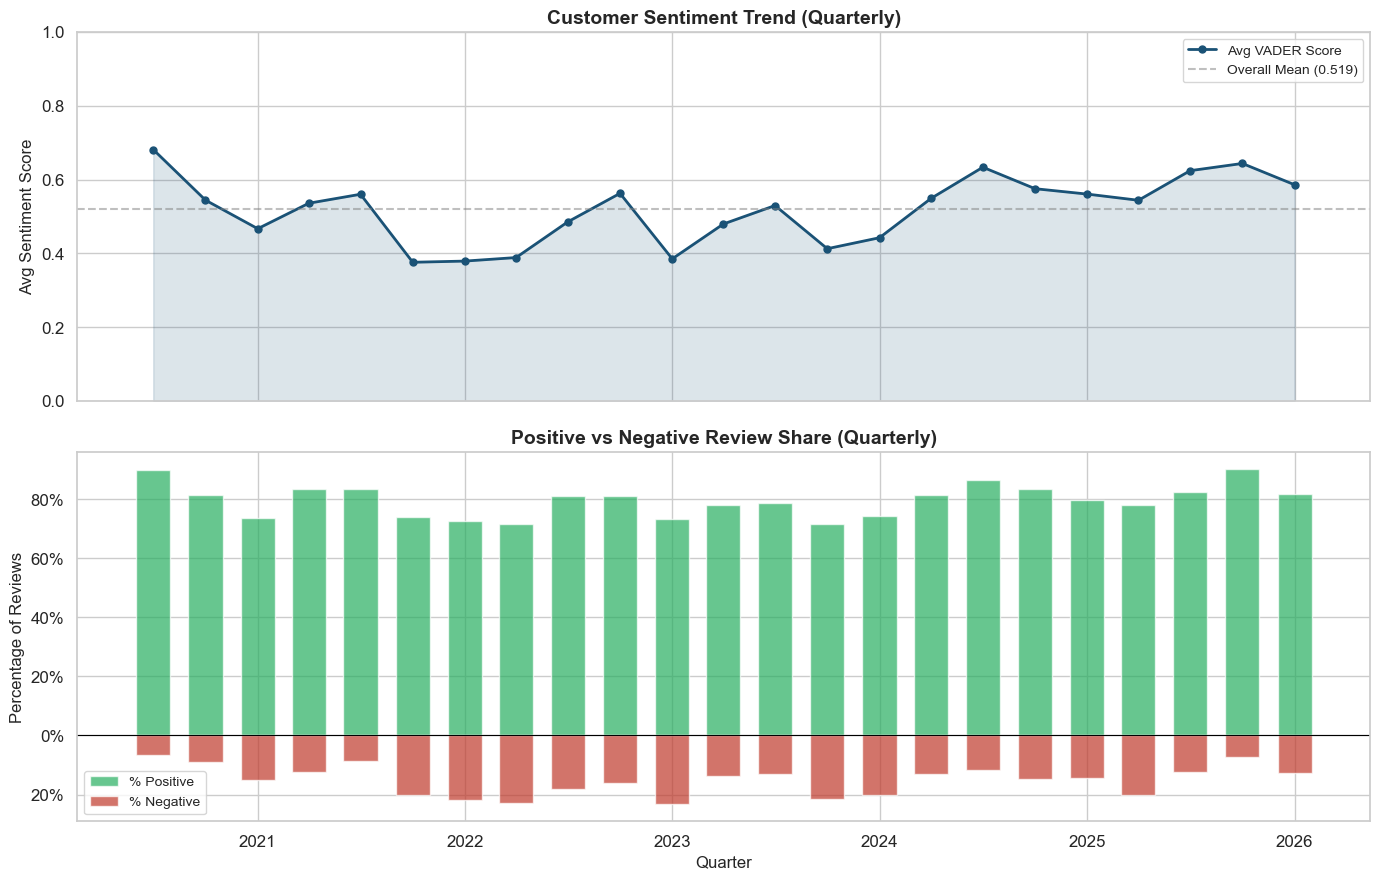

In [12]:
# quarterly sentiment trend
df["quarter"] = df["date"].dt.to_period("Q")
quarterly = df.groupby("quarter").agg(
    avg_vader=("vader_compound", "mean"),
    avg_stars=("total_score", "mean"),
    pct_positive=("vader_label", lambda x: (x == "Positive").mean()),
    pct_negative=("vader_label", lambda x: (x == "Negative").mean()),
    count=("total_score", "count")
).reset_index()
quarterly["quarter_ts"] = quarterly["quarter"].dt.to_timestamp()

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

# --- Top: Sentiment score trend ---
axes[0].plot(quarterly["quarter_ts"], quarterly["avg_vader"], "o-", color=SHEA_BLUE,
             linewidth=2, markersize=5, label="Avg VADER Score")
axes[0].fill_between(quarterly["quarter_ts"], quarterly["avg_vader"], alpha=0.15, color=SHEA_BLUE)
axes[0].axhline(y=quarterly["avg_vader"].mean(), color="gray", linestyle="--", alpha=0.5,
                label=f"Overall Mean ({quarterly['avg_vader'].mean():.3f})")
axes[0].set_ylabel("Avg Sentiment Score", fontsize=12)
axes[0].set_title("Customer Sentiment Trend (Quarterly)", fontsize=14, fontweight="bold")
axes[0].legend(fontsize=10)
axes[0].set_ylim(0, 1)

# --- Bottom: Positive vs Negative % ---
axes[1].bar(quarterly["quarter_ts"], quarterly["pct_positive"] * 100, width=60,
            color="#27ae60", alpha=0.7, label="% Positive")
axes[1].bar(quarterly["quarter_ts"], -quarterly["pct_negative"] * 100, width=60,
            color="#c0392b", alpha=0.7, label="% Negative")
axes[1].axhline(y=0, color="black", linewidth=0.8)
axes[1].set_ylabel("Percentage of Reviews", fontsize=12)
axes[1].set_xlabel("Quarter", fontsize=12)
axes[1].set_title("Positive vs Negative Review Share (Quarterly)", fontsize=14, fontweight="bold")
axes[1].legend(fontsize=10, loc="lower left")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{abs(x):.0f}%"))

plt.tight_layout()
plt.savefig("sentiment_trend.png", dpi=150, bbox_inches="tight")
plt.show()

Customer sentiment remains consistently positive throughout the period, with average sentiment scores generally staying between 0.4 and 0.7 on the VADER scale. The share of positive reviews typically ranges between 70% and 85%, while negative reviews remain a much smaller portion of the dataset. Overall, the charts show no major long-term decline or improvement in sentiment, suggesting that customer satisfaction has remained relatively stable over time.


## 3.4 Sentiment by State
This chart compares customer sentiment across states using the VADER sentiment score. Each bar represents the average sentiment of review text within a state. Higher scores indicate that customers in that market tend to describe their experience using more positive language.

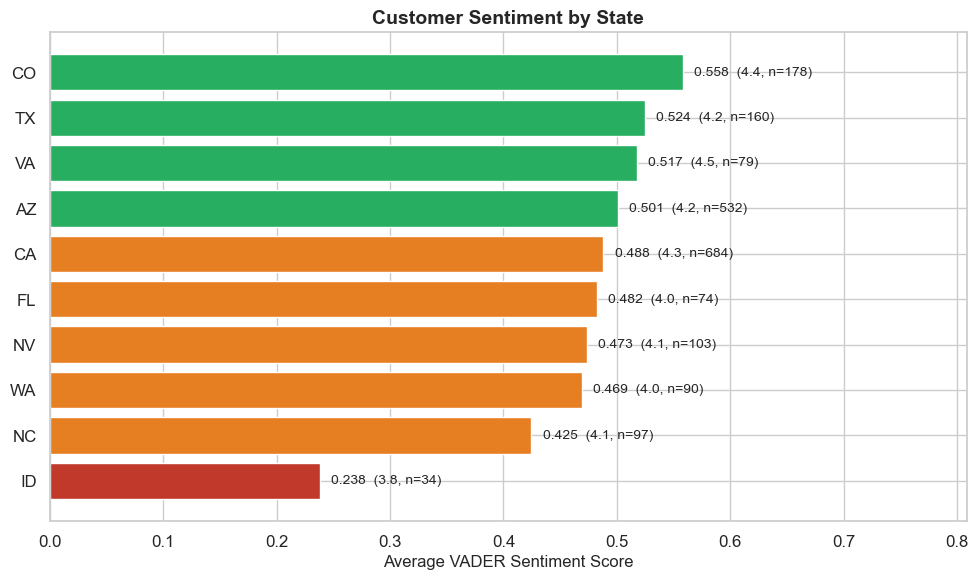

In [13]:
state_sent = df.groupby("state").agg(
    avg_vader=("vader_compound", "mean"),
    avg_stars=("total_score", "mean"),
    pct_negative=("vader_label", lambda x: (x == "Negative").mean()),
    count=("total_score", "count")
).sort_values("avg_vader", ascending=True)
state_sent = state_sent[state_sent["count"] >= 10]

fig, ax = plt.subplots(figsize=(10, 6))
bar_colors = ["#27ae60" if v >= 0.5 else "#e67e22" if v >= 0.3 else "#c0392b" for v in state_sent["avg_vader"]]
bars = ax.barh(state_sent.index, state_sent["avg_vader"], color=bar_colors, edgecolor="white")

for bar, vader, stars, count in zip(bars, state_sent["avg_vader"], state_sent["avg_stars"], state_sent["count"]):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f"{vader:.3f}  ({stars:.1f}, n={count})",
            ha="left", va="center", fontsize=10)

ax.set_xlabel("Average VADER Sentiment Score", fontsize=12)
ax.set_title("Customer Sentiment by State", fontsize=14, fontweight="bold")
ax.set_xlim(0, max(state_sent["avg_vader"]) + 0.25)

plt.tight_layout()
plt.savefig("sentiment_by_state.png", dpi=150, bbox_inches="tight")
plt.show()

Most states show consistently positive sentiment, with scores clustering between 0.45 and 0.55. Colorado and Texas rank among the highest, showing positive review language in those markets.

North Carolina and Idaho appear lower in comparison, suggesting that customer experiences in those markets may warrant closer examination. California and Arizona, the two markets with the largest number of reviews, remain positive, showing stable customer sentiment in Shea Homes’ largest operating regions.


## 3.5 What Are Unhappy Customers Talking About?
This analysis examines the most frequently used words in positive and negative reviews. The charts compare language used in 1–2 star reviews with language used in 4–5 star reviews. By analyzing which terms appear most often in each group, we can identify the themes that customers associate with positive experiences and the issues that appear most often in negative feedback.


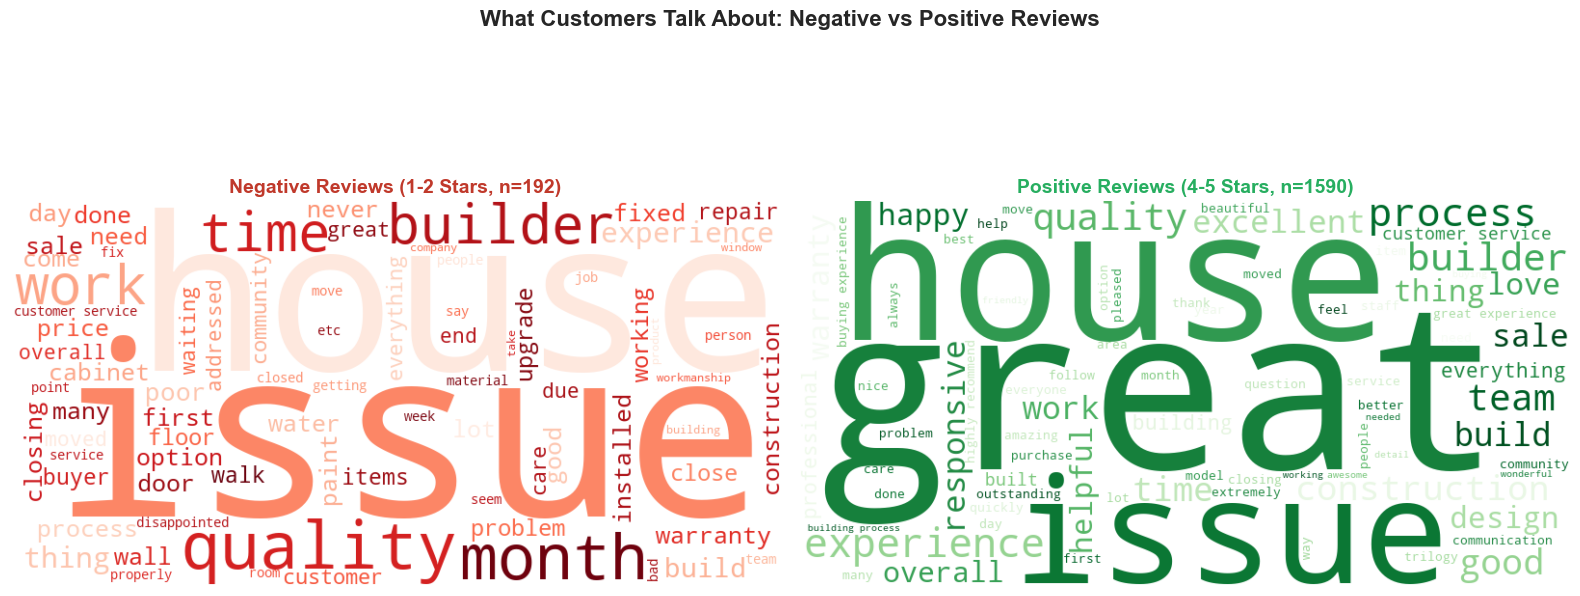

In [14]:
stop_words = set(stopwords.words("english"))
# add domain-specific stop words that aren't meaningful 
stop_words.update([
    "home", "shea", "homes", "new", "would", "one", "us",
    "also", "get", "got", "even", "like", "really", "much",
    "could", "said", "told", "went", "going", "still", "back",
    "made", "make", "well", "since", "every"
])

def get_clean_words(texts):
    """Extract meaningful words from a collection of review texts."""
    all_text = " ".join(texts.astype(str)).lower()
    words = re.findall(r"[a-z']+", all_text)
    return [w for w in words if w not in stop_words and len(w) > 2]

# split into groups based on star rating for cleaner separation
neg_reviews = df[df["total_score"] <= 2]["review_text"]
pos_reviews = df[df["total_score"] >= 4]["review_text"]

neg_words = get_clean_words(neg_reviews)
pos_words = get_clean_words(pos_reviews)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# negative word cloud
if neg_words:
    wc_neg = WordCloud(width=800, height=400, background_color="white",
                       colormap="Reds", max_words=80, min_font_size=10).generate(" ".join(neg_words))
    axes[0].imshow(wc_neg, interpolation="bilinear")
axes[0].set_title(f"Negative Reviews (1-2 Stars, n={len(neg_reviews)})", fontsize=14, fontweight="bold", color="#c0392b")
axes[0].axis("off")

# positive word cloud
if pos_words:
    wc_pos = WordCloud(width=800, height=400, background_color="white",
                       colormap="Greens", max_words=80, min_font_size=10).generate(" ".join(pos_words))
    axes[1].imshow(wc_pos, interpolation="bilinear")
axes[1].set_title(f"Positive Reviews (4-5 Stars, n={len(pos_reviews)})", fontsize=14, fontweight="bold", color="#27ae60")
axes[1].axis("off")

plt.suptitle("What Customers Talk About: Negative vs Positive Reviews", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("word_clouds.png", dpi=150, bbox_inches="tight")
plt.show()

Negative reviews frequently reference words such as issues, quality, warranty, time, and construction, indicating that dissatisfaction is often related to build quality or delays in resolving problems after purchase. In contrast, positive reviews emphasize words such as experience, team, process, and service, suggesting that customers frequently highlight interactions with staff and the overall buying process when describing a positive experience. This contrast suggests that customer-facing interactions are a key strength, while product quality and issue resolution appear more often in negative feedback.

## 3.6 Most Common Themes in Negative Reviews

This table identifies words that appear disproportionately often in negative reviews compared with positive reviews. Instead of simply counting the most common words, the analysis measures how much more frequently a word appears in complaints than in positive feedback. Words with high overrepresentation scores are strongly associated with dissatisfied customer experiences.

In [15]:
# count the most common meaningful words in negative vs positive reviews
neg_counter = Counter(neg_words)
pos_counter = Counter(pos_words)

# find words that are disproportionately common in negative reviews
# (normalized by group size to account for different sample sizes)
neg_rate = {w: c / len(neg_reviews) for w, c in neg_counter.most_common(200)}
pos_rate = {w: c / len(pos_reviews) for w, c in pos_counter.most_common(200)}

# words much more common in negative reviews
neg_distinctive = []
for word, rate in sorted(neg_rate.items(), key=lambda x: -x[1]):
    pos_r = pos_rate.get(word, 0.001)
    ratio = rate / pos_r
    if ratio > 1.5 and neg_counter[word] >= 10:
        neg_distinctive.append((word, neg_counter[word], ratio))

print("WORDS UNIQUELY COMMON IN NEGATIVE REVIEWS (1-2 stars)")
print("These words appear much more frequently in bad reviews than good ones.")
print("=" * 60)
print(f"{'Word':<20} {'Count':<10} {'Overrepresentation':<20}")
print("-" * 60)
for word, count, ratio in sorted(neg_distinctive, key=lambda x: -x[2])[:20]:
    print(f"{word:<20} {count:<10} {ratio:.1f}x more than positive")

WORDS UNIQUELY COMMON IN NEGATIVE REVIEWS (1-2 stars)
These words appear much more frequently in bad reviews than good ones.
Word                 Count      Overrepresentation  
------------------------------------------------------------
poor                 37         192.7x more than positive
installed            27         140.6x more than positive
bad                  25         130.2x more than positive
list                 24         125.0x more than positive
cabinets             21         109.4x more than positive
waiting              21         109.4x more than positive
disappointed         20         104.2x more than positive
point                19         99.0x more than positive
etc                  19         99.0x more than positive
closed               19         99.0x more than positive
properly             19         99.0x more than positive
contract             19         99.0x more than positive
wall                 18         93.8x more than positive
worst        

Words like poor (192.7x more common in negative reviews), installed (140.6x), cabinets (109.4x), and flooring (83.3x) point to specific construction pain points. The word waiting (109.4x) and months suggest delays are a major theme. These are not abstract complaints; they are about specific, fixable things: cabinets installed wrong, flooring issues, and long wait times for repairs.

## 3.7 Score vs. Sentiment Mismatch

This section identifies reviews where the star rating and the language of the review do not align. In most cases, higher star ratings are associated with positive wording, while lower ratings contain more negative language. When these signals disagree, it can show more complexity in the customer experience that star ratings alone may not capture.

One important category is high-star reviews with negative sentiment in the text. These reviews often show that a customer was generally satisfied but still experienced specific problems worth noting. Identifying these cases helps surface issues that may otherwise be overlooked when focusing only on low star ratings.


In [16]:
# find mismatches: high stars but negative text, or low stars but positive text
df["mismatch"] = False

# high stars (4-5) but negative sentiment
high_star_neg = (df["total_score"] >= 4) & (df["vader_compound"] < -0.05)
# low stars (1-2) but positive sentiment  
low_star_pos = (df["total_score"] <= 2) & (df["vader_compound"] > 0.5)

df.loc[high_star_neg | low_star_pos, "mismatch"] = True

print(f"Total mismatch reviews: {df['mismatch'].sum()} ({df['mismatch'].mean():.1%} of all reviews)")
print(f"  High stars, negative text: {high_star_neg.sum()}")
print(f"  Low stars, positive text:  {low_star_pos.sum()}")

# show some examples of high-star negative-text reviews (hidden complaints)
print("\n" + "=" * 70)
print("HIDDEN COMPLAINTS: Customers gave 4-5 stars but wrote negative text")
print("These are customers who were generally happy but had specific issues.")
print("=" * 70)

hidden_complaints = df[high_star_neg].sort_values("vader_compound").head(5)
for _, row in hidden_complaints.iterrows():
    print(f"\n{row['total_score']} Stars| VADER: {row['vader_compound']:.3f} | {row['location']}")
    print(f"  \"{row['review_text'][:250]}{'...' if len(str(row['review_text'])) > 250 else ''}\"")

Total mismatch reviews: 146 (7.2% of all reviews)
  High stars, negative text: 110
  Low stars, positive text:  36

HIDDEN COMPLAINTS: Customers gave 4-5 stars but wrote negative text
These are customers who were generally happy but had specific issues.

5 Stars| VADER: -0.991 | Conroe, TX
  "The subcontractor PSG Landscaping is ruining your reputation as a stellar builder. Between the combination of our warranty manager and PSG, our experience is: • Both our front and back lawns are completely riddled with lumps under the grass where you..."

5 Stars| VADER: -0.987 | Avondale, AZ
  "The house is beautifull from the display but once you settle in things begin to appear out of place. I give an overall 3-star experince because the sellers witheld critical information or bully me after I signed the deal and found issues that needed ..."

4 Stars| VADER: -0.973 | Littleton, CO
  "The majority of the experience has been awesome. Many of the personnel with whom we have interacted have been o

A total of 146 reviews (7.2% of the dataset) show a mismatch between the rating and the sentiment expressed in the text. The majority of these cases, 110 reviews, are high-star ratings paired with negative language, indicating customers who reported specific issues despite assigning an overall positive score. These reviews are particularly valuable from an operational perspective. Because the customer still left a favorable rating, the relationship is largely intact, yet the written feedback highlights clear opportunities for improvement, such as subcontractor performance, installation quality, or post-closing service.

## 3.8 Sample Reviews by Sentiment
To show how the sentiment models interpret review text, this section gives real examples from the dataset across different sentiment categories. These examples help translate the numerical sentiment scores into the type of language customers actually use when describing their experiences.


In [17]:
def show_reviews(label, n=3):
    """Display sample reviews for a given sentiment category."""
    if label == "Positive":
        subset = df[df["vader_label"] == label].nlargest(n, "vader_compound")
    elif label == "Negative":
        subset = df[df["vader_label"] == label].nsmallest(n, "vader_compound")
    else:
        subset = df[df["vader_label"] == label].head(n)
    
    for _, row in subset.iterrows():
        print(f"{row['total_score']} Stars | {row['location']} | {row['date'].strftime('%b %Y')} | VADER: {row['vader_compound']:.3f}")
        text = str(row["review_text"])
        print(f"  \"{text[:300]}{'...' if len(text) > 300 else ''}\"")
        print()

print("=" * 70)
print("MOST POSITIVE REVIEWS (highest sentiment scores)")
print("=" * 70)
show_reviews("Positive")

print("=" * 70)
print("MOST NEGATIVE REVIEWS (lowest sentiment scores)")
print("=" * 70)
show_reviews("Negative")

print("=" * 70)
print("NEUTRAL REVIEWS (mixed or factual tone)")
print("=" * 70)
show_reviews("Neutral")

MOST POSITIVE REVIEWS (highest sentiment scores)
5 Stars | Cave Creek, AZ | May 2025 | VADER: 0.999
  "The Sales team at The Reserves Lone Mountain was always helpful, responsive and made the process less stressful. Overall I give the sales Team 5 stars. Everyone was always helpful and sincerely cared for my concerns. The only thing that is stressful is that non of the other departments that handle e..."

5 Stars | Mission Viejo, CA | Jun 2023 | VADER: 0.998
  "I recently had the pleasure of working with Shea Homes® Neo at Mission Foothills Builder for the construction of my new home, and I couldn't be more pleased with the experience. From start to finish, they demonstrated a commitment to excellence, delivering my home on time and surpassing my expectati..."

5 Stars | Peoria, AZ | Jan 2025 | VADER: 0.998
  "Our experience with Shea Homes has been outstanding from start to finish, and we are absolutely thrilled with our new home in the Aloravita community! From the very first moment 

Positive reviews typically contain enthusiastic language and references to specific employees, teams, or smooth buying experiences. Negative reviews, in contrast, tend to focus on specific construction defects, installation problems, or delays in resolving issues. Neutral reviews generally contain short or factual statements with little emotional language, which results in sentiment scores near zero. Reviewing these examples provides context for how the sentiment algorithms classify text and what each sentiment category represents in practice.


---
# Part 4: Advanced Sentiment Analysis

This section applies advanced natural language processing (NLP) techniques to find insights from customer reviews. Rather than only measuring whether reviews are positive or negative, these methods analyze the text to identify recurring themes, frequently discussed topics, and patterns in how customers describe their experiences.

The analysis also looks for which aspects of the homebuying experience customers mention most often, such as sales interactions, construction quality, or warranty service. By analyzing groups of words and phrases together, these techniques show more detailed patterns in customer feedback and help find the specific areas of the business that drive satisfaction or dissatisfaction.

---
# 4.1 Topic Discovery (LDA)

This section uses a technique called topic modeling to automatically identify the main subjects customers discuss in their reviews. The specific method used, Latent Dirichlet Allocation (LDA), analyzes patterns of words that frequently appear together across the dataset. Reviews that contain similar groups of words are grouped into a shared topic, allowing the model to discover common themes without being manually labeled in advance.

By applying this approach to all reviews, the model identifies the major themes in customer feedback, such as construction quality, the buying process, sales interactions, and post-purchase issues. This provides a structured overview of what customers talk about most often.

In [18]:
count_vec = CountVectorizer(
    max_features=2000,
    stop_words=list(stop_words),
    min_df=5,
    max_df=0.7,
    ngram_range=(1, 2),
)

doc_term_matrix = count_vec.fit_transform(df["review_text"].astype(str))
feature_names = count_vec.get_feature_names_out()

print(f"Text converted to numbers: {doc_term_matrix.shape[0]} reviews × {doc_term_matrix.shape[1]} unique terms")

Text converted to numbers: 2039 reviews × 2000 unique terms


In [19]:
# run LDA topic modeling 
N_TOPICS = 6

lda = LatentDirichletAllocation(
    n_components=N_TOPICS,
    random_state=42,
    max_iter=25,
    learning_method="online",
)
lda.fit(doc_term_matrix)

# assign human-readable labels based on the top words in each topic
print("=" * 70)
print("Topics")
print("=" * 70)

topic_keywords = []
for idx, topic in enumerate(lda.components_):
    top_words = [feature_names[i] for i in topic.argsort()[-12:][::-1]]
    topic_keywords.append(top_words)
    print(f"\n  Topic {idx + 1}: {', '.join(top_words[:8])}")
    print(f"           {', '.join(top_words[8:])}")

Topics

  Topic 1: house, quality, door, water, work, paint, price, issue
           lot, installed, garage, many

  Topic 2: issues, experience, quality, great, process, team, buying, work
           overall, sales, warranty, closing

  Topic 3: issues, things, done, time, fixed, items, need, months
           list, day, warranty, waiting

  Topic 4: service, customer, customer service, great, quality, excellent, builder, work
           good, love, construction, best

  Topic 5: experience, process, great, design, building, build, sales, time
           construction, manager, team, first

  Topic 6: house, good, person, sales, love, end, experience, closing
           attention, construction, great, beautiful


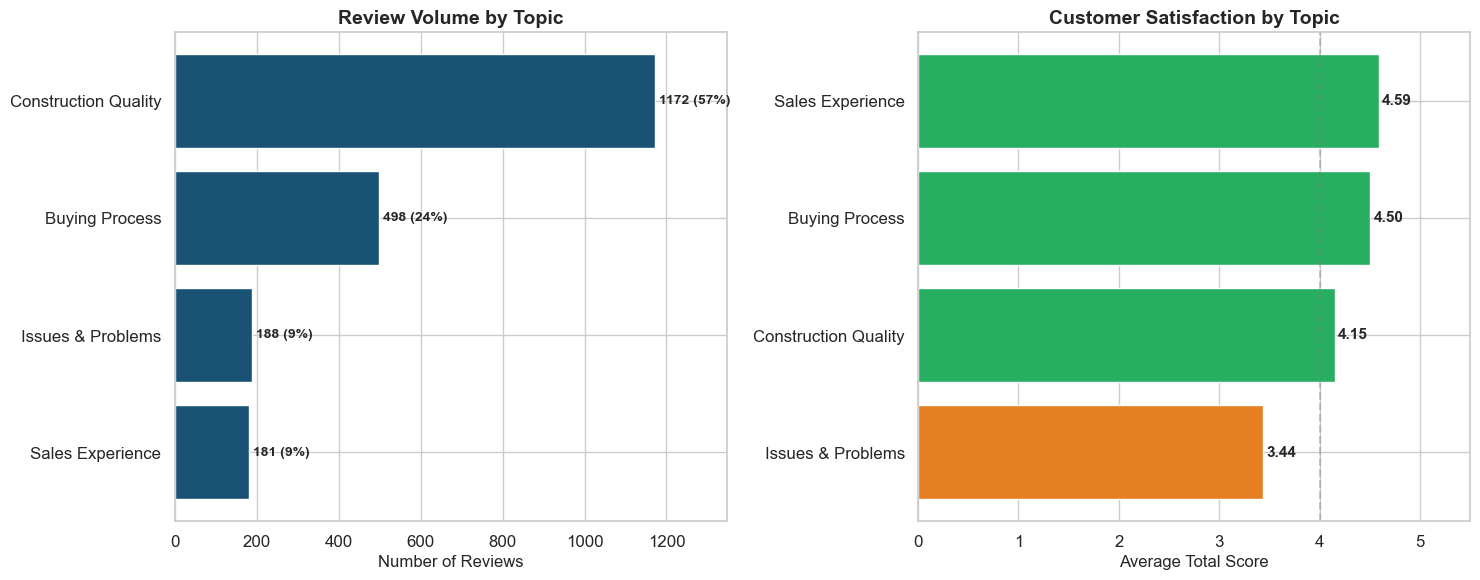

In [20]:
# assign each review its dominant topic
topic_distributions = lda.transform(doc_term_matrix)
df["dominant_topic"] = topic_distributions.argmax(axis=1) + 1  # 1-indexed
df["topic_confidence"] = topic_distributions.max(axis=1)

# let users define topic names after seeing the keywords above
# these are reasonable defaults based on typical Shea review content
TOPIC_NAMES = {}
for i in range(1, N_TOPICS + 1):
    TOPIC_NAMES[i] = f"Topic {i}"

# auto-label based on keyword content
label_hints = {
    "sales": "Sales Experience",
    "warranty": "Warranty & Post-Purchase",
    "quality": "Construction Quality",
    "community": "Community & Lifestyle",
    "process": "Buying Process",
    "team": "Team & Communication",
    "design": "Design & Features",
    "price": "Value & Pricing",
    "construction": "Construction Quality",
    "move": "Move-In Experience",
    "closing": "Closing Process",
    "issues": "Issues & Problems",
    "response": "Responsiveness",
}

for topic_num, keywords in enumerate(topic_keywords, 1):
    for keyword, label in label_hints.items():
        if any(keyword in kw for kw in keywords[:6]):
            TOPIC_NAMES[topic_num] = label
            break

df["topic_name"] = df["dominant_topic"].map(TOPIC_NAMES)

# visualize topic distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# left: topic frequency
topic_counts = df["topic_name"].value_counts()
axes[0].barh(topic_counts.index[::-1], topic_counts.values[::-1], color=SHEA_BLUE, edgecolor="white")
max_val = topic_counts.max()
axes[0].set_xlim(0, max_val * 1.15)
for i, (val, name) in enumerate(zip(topic_counts.values[::-1], topic_counts.index[::-1])):
    axes[0].text(val + 10, i, f"{val} ({val/len(df):.0%})", va="center", fontsize=10, fontweight="bold")
axes[0].set_xlabel("Number of Reviews", fontsize=12)
axes[0].set_title("Review Volume by Topic", fontsize=14, fontweight="bold")

# right: avg score by topic
topic_scores = df.groupby("topic_name")["total_score"].mean().sort_values()
colors = ["#27ae60" if v >= 4.0 else "#e67e22" if v >= 3.0 else "#c0392b" for v in topic_scores]
axes[1].barh(topic_scores.index, topic_scores.values, color=colors, edgecolor="white")
for i, (val, name) in enumerate(zip(topic_scores.values, topic_scores.index)):
    axes[1].text(val + 0.03, i, f"{val:.2f}", va="center", fontsize=11, fontweight="bold")
axes[1].set_xlim(0, 5.5)
axes[1].set_xlabel("Average Total Score", fontsize=12)
axes[1].set_title("Customer Satisfaction by Topic", fontsize=14, fontweight="bold")
axes[1].axvline(x=4.0, color="gray", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

The algorithm discovered 6 distinct topics without any guidance. Construction quality appears most frequently, representing the largest share of customer discussion. Topics related to the buying process and sales experience also appear often and tend to receive the highest satisfaction scores. In contrast, reviews grouped under issues and problems show noticeably lower satisfaction levels. This pattern suggests that while the sales and purchasing experience is generally well received, dissatisfaction is more commonly associated with construction defects or post-delivery service issues.


---
# 4.2 Aspect-Based Sentiment Analysis

Aspect-based sentiment analysis examines how customers feel about specific parts of the homebuying experience. Instead of assigning a single sentiment score to an entire review, this method identifies mentions of key business areas (sales, construction quality, warranty service, communication, design, and pricing) and measures sentiment for each one separately.

This approach is useful because customers often discuss multiple aspects within the same review. For example, a customer may write one sentence praising the sales team and another complaining about drywall cracks. Aspect-based sentiment analysis evaluates each of these mentions separately, scoring the sales interaction as positive and the construction issue as negative rather than averaging the entire review into a single score.

In [21]:
# define aspect keyword dictionaries
# if a review mentions these words, we know it's discussing that aspect
ASPECTS = {
    "Sales & Buying Process": [
        "sales", "buying", "purchase", "contract", "closing", "escrow",
        "realtor", "agent", "sales rep", "sales team", "deposit",
        "financing", "mortgage", "loan", "interest rate", "pre-approval",
    ],
    "Construction Quality": [
        "quality", "construction", "build", "built", "craftsmanship",
        "materials", "drywall", "paint", "flooring", "foundation",
        "plumbing", "electrical", "roof", "windows", "doors", "cabinets",
        "concrete", "cracks", "defects", "defect", "workmanship",
    ],
    "Communication & Responsiveness": [
        "communication", "responsive", "response", "respond", "answered",
        "call", "email", "phone", "update", "informed", "transparent",
        "kept us", "follow up", "follow-up", "reached out", "timely",
        "ignored", "never called", "no response", "ghosted",
    ],
    "Warranty & Post-Move": [
        "warranty", "repair", "fix", "fixed", "issue", "issues",
        "problem", "problems", "maintenance", "service request",
        "punch list", "walk-through", "walkthrough", "inspection",
        "one month", "30 day", "post-close", "after moving",
    ],
    "Design & Floor Plan": [
        "design", "floor plan", "layout", "floorplan", "model",
        "upgrade", "upgrades", "options", "features", "kitchen",
        "bathroom", "bedroom", "backyard", "garage", "space",
        "spacious", "open concept", "modern", "finishes", "countertop",
    ],
    "Value & Pricing": [
        "value", "price", "pricing", "cost", "expensive", "affordable",
        "worth", "money", "overpriced", "budget", "hoa", "fees",
        "investment", "deal", "incentive", "discount", "rate",
    ],
}

def get_aspect_sentiment(text, aspect_keywords):
    """
    For a given review, check if it mentions a specific aspect.
    If it does, extract the sentences mentioning it and score their sentiment.
    Returns (mentioned: bool, sentiment_score: float or None)
    """
    text_lower = str(text).lower()
    
    # check if any keywords are mentioned
    mentioned_sentences = []
    sentences = re.split(r'[.!?]+', text_lower)
    
    for sentence in sentences:
        if any(kw in sentence for kw in aspect_keywords):
            mentioned_sentences.append(sentence.strip())
    
    if not mentioned_sentences:
        return False, None
    
    # score sentiment of the relevant sentences only
    combined = ". ".join(mentioned_sentences)
    score = sia.polarity_scores(combined)["compound"]
    return True, score

aspect_results = {}
for aspect, keywords in ASPECTS.items():
    mentions = []
    sentiments = []
    for text in df["review_text"]:
        mentioned, score = get_aspect_sentiment(text, keywords)
        mentions.append(mentioned)
        sentiments.append(score)
    
    df[f"asp_{aspect}_mentioned"] = mentions
    df[f"asp_{aspect}_sentiment"] = sentiments
    
    n_mentioned = sum(mentions)
    valid_scores = [s for s in sentiments if s is not None]
    avg_sent = np.mean(valid_scores) if valid_scores else 0
    pct_neg = np.mean([s < -0.05 for s in valid_scores]) if valid_scores else 0
    
    aspect_results[aspect] = {
        "mentions": n_mentioned,
        "pct_reviews": n_mentioned / len(df),
        "avg_sentiment": avg_sent,
        "pct_negative": pct_neg,
    }
    
    print(f"  {aspect:<35} | {n_mentioned:>5} mentions ({n_mentioned/len(df):>5.0%}) | Avg sentiment: {avg_sent:>+.3f} | {pct_neg:.0%} negative")

  Sales & Buying Process              |   839 mentions (  41%) | Avg sentiment: +0.349 | 15% negative
  Construction Quality                |  1100 mentions (  54%) | Avg sentiment: +0.276 | 21% negative
  Communication & Responsiveness      |   703 mentions (  34%) | Avg sentiment: +0.337 | 14% negative
  Warranty & Post-Move                |   749 mentions (  37%) | Avg sentiment: +0.183 | 25% negative
  Design & Floor Plan                 |   513 mentions (  25%) | Avg sentiment: +0.258 | 22% negative
  Value & Pricing                     |   370 mentions (  18%) | Avg sentiment: +0.239 | 23% negative


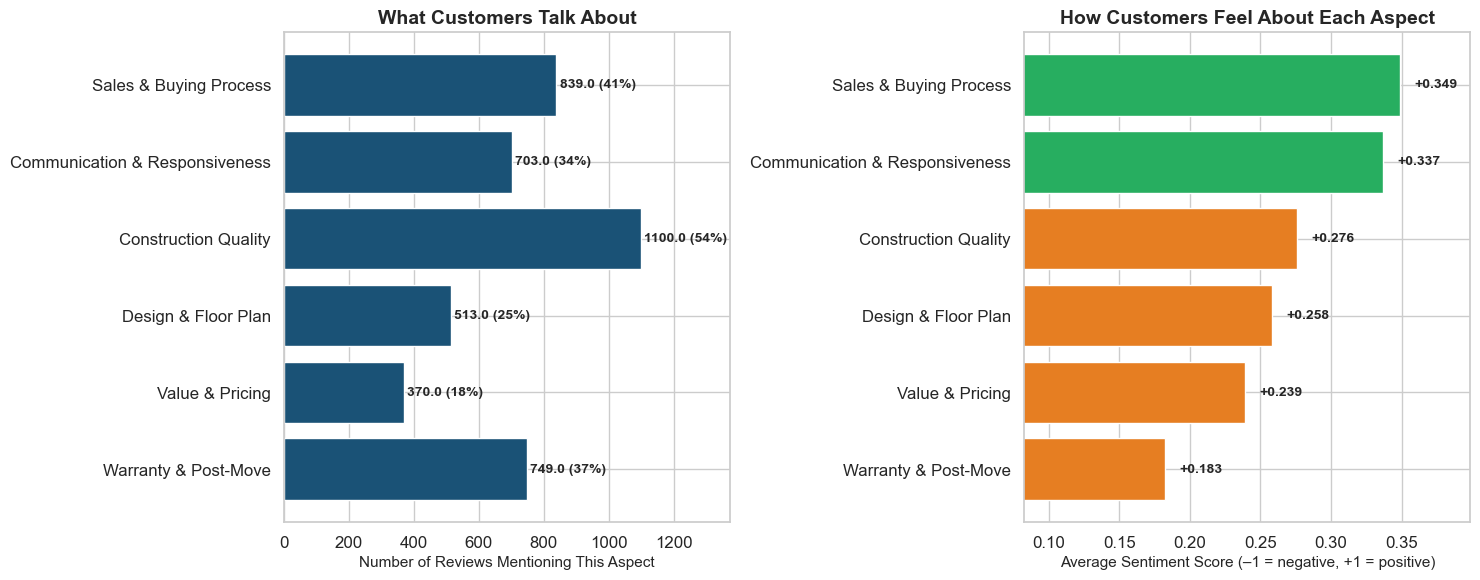

In [22]:
# visualize aspect-based results
asp_df = pd.DataFrame(aspect_results).T.sort_values("avg_sentiment")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# left: how often each aspect is mentioned
axes[0].barh(asp_df.index, asp_df["mentions"], color=SHEA_BLUE, edgecolor="white")
max_mentions = asp_df["mentions"].max()
axes[0].set_xlim(0, max_mentions * 1.25)
for i, (val, pct) in enumerate(zip(asp_df["mentions"], asp_df["pct_reviews"])):
    axes[0].text(val + 10, i, f"{val} ({pct:.0%})", va="center", fontsize=10, fontweight="bold")
axes[0].set_xlabel("Number of Reviews Mentioning This Aspect", fontsize=11)
axes[0].set_title("What Customers Talk About", fontsize=14, fontweight="bold")

# right: sentiment by aspect
colors = ["#27ae60" if v >= 0.3 else "#e67e22" if v >= 0.1 else "#c0392b" for v in asp_df["avg_sentiment"]]
axes[1].barh(asp_df.index, asp_df["avg_sentiment"], color=colors, edgecolor="white")
max_sent = asp_df["avg_sentiment"].max()
min_sent = asp_df["avg_sentiment"].min()
axes[1].set_xlim(min_sent - 0.1, max_sent + 0.05)
for i, val in enumerate(asp_df["avg_sentiment"]):
    axes[1].text(val + 0.01 if val >= 0 else val - 0.06, i, f"{val:+.3f}", va="center", fontsize=10, fontweight="bold")
axes[1].set_xlabel("Average Sentiment Score (–1 = negative, +1 = positive)", fontsize=11)
axes[1].set_title("How Customers Feel About Each Aspect", fontsize=14, fontweight="bold")
axes[1].axvline(x=0, color="black", linewidth=0.8)

plt.tight_layout()
plt.savefig("aspect_sentiment.png", dpi=150, bbox_inches="tight")
plt.show()

weakest = asp_df["avg_sentiment"].idxmin()
strongest = asp_df["avg_sentiment"].idxmax()

Construction quality is the most frequently discussed topic, appearing in more than half of all reviews. However, it also shows lower sentiment scores compared with other aspects, indicating that many customer concerns are tied to the physical build or post-construction issues. In contrast, sales interactions and communication receive the strongest sentiment scores, suggesting that customers generally view the front-end buying experience positively. Warranty and post-move service shows the weakest sentiment, highlighting it as an area where improvements could have a meaningful impact on overall customer satisfaction.


---
# 4.3 Employee Recognition Mining

Customers often mention Shea team members by name in their reviews. This section scans through all 2,039 reviews, looks for names, and then reads the sentences around each name to figure out whether the customer was saying something positive or negative about that person. This is useful for identifying top performers who consistently get praised, or for spotting cases where a specific team member keeps coming up in negative contexts.

In [23]:
# extract proper names from reviews using pattern matching
# we look for capitalized words that appear to be first names

# common english words that are capitalized but NOT names
NOT_NAMES = {
    "The", "We", "Our", "They", "He", "She", "It", "My", "Very", "This",
    "That", "From", "Would", "Every", "And", "But", "For", "Not", "All",
    "Are", "Was", "Has", "Had", "Been", "Will", "Can", "Just", "Great",
    "Good", "Best", "Much", "Only", "After", "With", "When", "What",
    "How", "Which", "Their", "There", "Here", "Also", "Even", "More",
    "Most", "Some", "Any", "Other", "Each", "Into", "Over", "About",
    "Through", "During", "Before", "Below", "Between", "Both", "Never",
    "Excellent", "Amazing", "Outstanding", "Quality", "Home", "Homes",
    "Shea", "Everything", "Beautiful", "Whole", "Highly", "Professional",
    "Building", "Really", "First", "New", "Love", "Thank", "Loved",
    "Entire", "Process", "Experience", "Always", "Team", "Customer",
    "Service", "Construction", "Warranty", "Sales", "Buying", "House",
    "Community", "Floor", "Plan", "Recommend", "Well", "Working",
    "Year", "Time", "Day", "Way", "Lot", "Thank", "Overall", "Trilogy",
    "Made", "Make", "Keep", "Know", "Come", "Take", "Give", "Look",
    "Help", "Work", "Need", "Feel", "Call", "Move", "Try", "Start",
    "Still", "Covid", "HOA", "Design", "Manager", "Super", "Then",
    "Now", "Once", "Since", "While", "These", "Many", "Poor", "Field",
    "Thanks", "Mortgage", "Builder", "One", "You", "However",
    "Encanterra", "Trilogy", "Mesa", "Phoenix", "Denver", "Vegas",
    "Livermore", "Tracy", "Being", "Pleased", "Awesome", "Wonderful",
    "Especially", "Buying", "Told", "Going", "Done", "Took", "Did",
    "Though", "Absolutely", "Definitely", "Nothing", "Something",
    "Another", "Little", "Positive", "Negative", "Impressed",
    "Terrible", "Horrible", "Worst", "Fabulous", "Perfect", "Quick",
    "Responsive", "Happy", "Smooth", "Very", "Several", "Few", "Its",
    "Sheas", "Ive", "Weve", "Communication", "Were", "Everyone", "Ranch",
    "Please", "Although", "Center", "Having", "Shae", "Despite", "Dont",
    "Unfortunately", "Your", "His", "Lots", "Wickenburg", "Ill", "Follow",
    "Dunes", "Thats", "Multiple", "Project", "Post", "Lake"
}

def extract_employee_mentions(text):
    """Find likely employee first names in a review and their sentiment context."""
    words = str(text).split()
    names_found = []
    
    for i, word in enumerate(words):
        clean = re.sub(r"[^A-Za-z]", "", word)
        if (clean and clean[0].isupper() and len(clean) >= 3 
            and clean not in NOT_NAMES and clean.isalpha()
            and not clean.isupper()):  # skip ALL CAPS words
            # get surrounding context (5 words each side)
            start = max(0, i - 5)
            end = min(len(words), i + 6)
            context = " ".join(words[start:end])
            context_sentiment = sia.polarity_scores(context)["compound"]
            names_found.append((clean, context_sentiment))
    
    return names_found

# run extraction
all_employee_mentions = []
for idx, row in df.iterrows():
    mentions = extract_employee_mentions(row["review_text"])
    for name, sent in mentions:
        all_employee_mentions.append({
            "name": name,
            "sentiment": sent,
            "total_score": row["total_score"],
            "location": row["location"],
            "state": row["state"],
        })

emp_df = pd.DataFrame(all_employee_mentions)

# aggregate by employee name
emp_summary = emp_df.groupby("name").agg(
    mentions=("sentiment", "count"),
    avg_sentiment=("sentiment", "mean"),
    avg_stars=("total_score", "mean"),
    top_location=("location", lambda x: x.mode().iloc[0] if len(x) > 0 else "Unknown"),
).sort_values("mentions", ascending=False)

# filter to employees mentioned 10+ times (likely real staff, not noise)
emp_top = emp_summary[emp_summary["mentions"] >= 10].head(20)

print("=" * 75)
print("TOP EMPLOYEE MENTIONS")
print("=" * 75)
print(f"{'Name':<15} {'Mentions':<10} {'Avg Sentiment':<16} {'Avg Stars':<12} {'Primary Location'}")
print("-" * 75)
for name, row in emp_top.iterrows():
    print(f"{name:<15} {row['mentions']:<10.0f} {row['avg_sentiment']:>+.3f}           {row['avg_stars']:<12.1f} {row['top_location']}")



TOP EMPLOYEE MENTIONS
Name            Mentions   Avg Sentiment    Avg Stars    Primary Location
---------------------------------------------------------------------------
Mike            35         +0.277           4.4          Las Vegas, NV
Ryan            27         +0.395           4.3          Indio, CA
Josh            20         +0.220           4.2          Manvel, TX
Richard         17         +0.354           4.7          Indio, CA
Matt            17         +0.329           4.7          Conroe, TX
Scott           16         +0.169           4.1          Rio Verde, AZ
Rep             14         +0.338           3.6          Indio, CA
Jason           14         +0.385           4.2          Rio Verde, AZ
Dan             14         +0.298           4.6          OCALA, FL
James           13         +0.356           5.0          Peoria, AZ
Steve           11         +0.220           4.5          Rio Verde, AZ
Brandon         11         +0.412           4.9          Conroe, TX
Kara

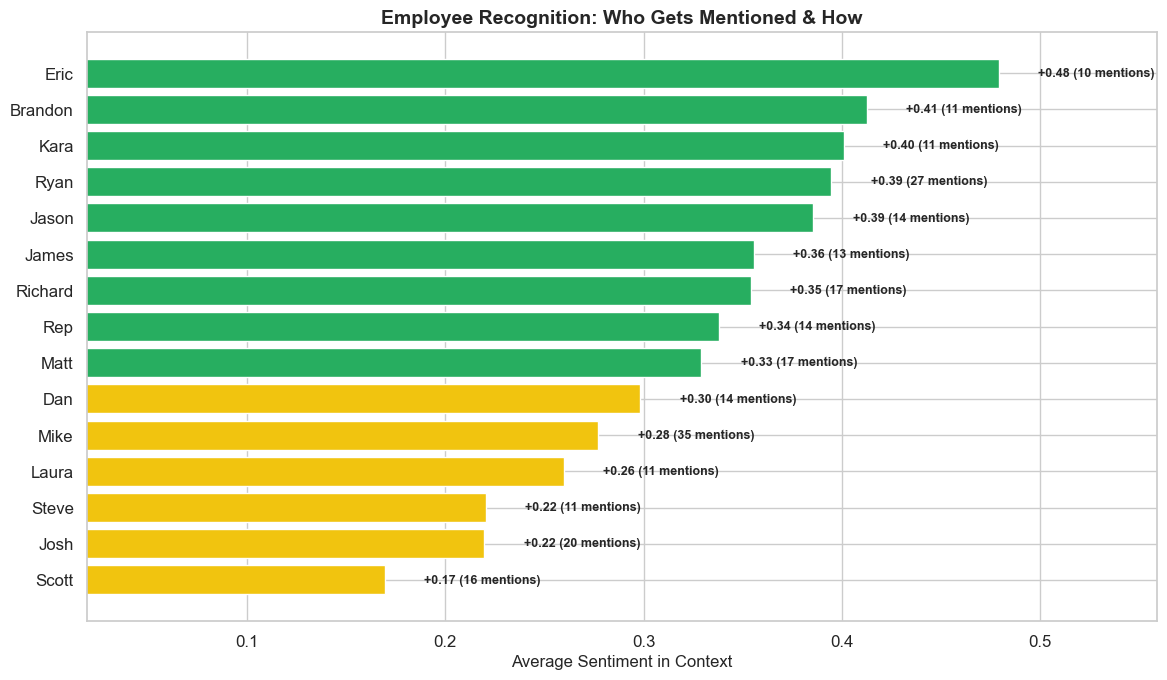

In [24]:
# visualize top 15 employees
emp_plot = emp_top.head(15).sort_values("avg_sentiment")

fig, ax = plt.subplots(figsize=(12, 7))
colors = ["#27ae60" if v >= 0.3 else "#f1c40f" if v >= 0 else "#c0392b" for v in emp_plot["avg_sentiment"]]
bars = ax.barh(emp_plot.index, emp_plot["avg_sentiment"], color=colors, edgecolor="white")
max_sent = emp_plot["avg_sentiment"].max()
min_sent = emp_plot["avg_sentiment"].min()

# add padding to axis
ax.set_xlim(min_sent - 0.15, max_sent + 0.08)

for bar, (name, row) in zip(bars, emp_plot.iterrows()):
    ax.text(bar.get_width() + 0.02 if bar.get_width() >= 0 else bar.get_width() - 0.08,
            bar.get_y() + bar.get_height()/2,
            f"{row['avg_sentiment']:+.2f} ({row['mentions']:.0f} mentions)",
            va="center", fontsize=9, fontweight="bold")

ax.set_xlabel("Average Sentiment in Context", fontsize=12)
ax.set_title("Employee Recognition: Who Gets Mentioned & How", fontsize=14, fontweight="bold")
ax.axvline(x=0, color="black", linewidth=0.8)

plt.tight_layout()
plt.show()

Mike in Las Vegas, Ryan in Indio, and Josh in Manvel are the most frequently mentioned employees, and all of them carry positive sentiment scores. That means when customers mention these people, they are saying good things. This kind of data could feed directly into recognition programs or performance reviews. It could also flag cases where a specific person keeps showing up in negative reviews, which would be an early signal for coaching or support.


---
# 4.4 Common Phrases Analysis (N-grams)

Earlier analysis looked at individual words, but meaning often comes from combinations of words. For example, the phrase “not responsive” carries the opposite meaning of the single word “responsive,” even though the word itself is positive.

This section analyzes common two-word and three-word phrases that appear frequently in positive and negative reviews. Looking at phrases instead of individual words provides a clearer picture of what customers are actually describing in their experiences.

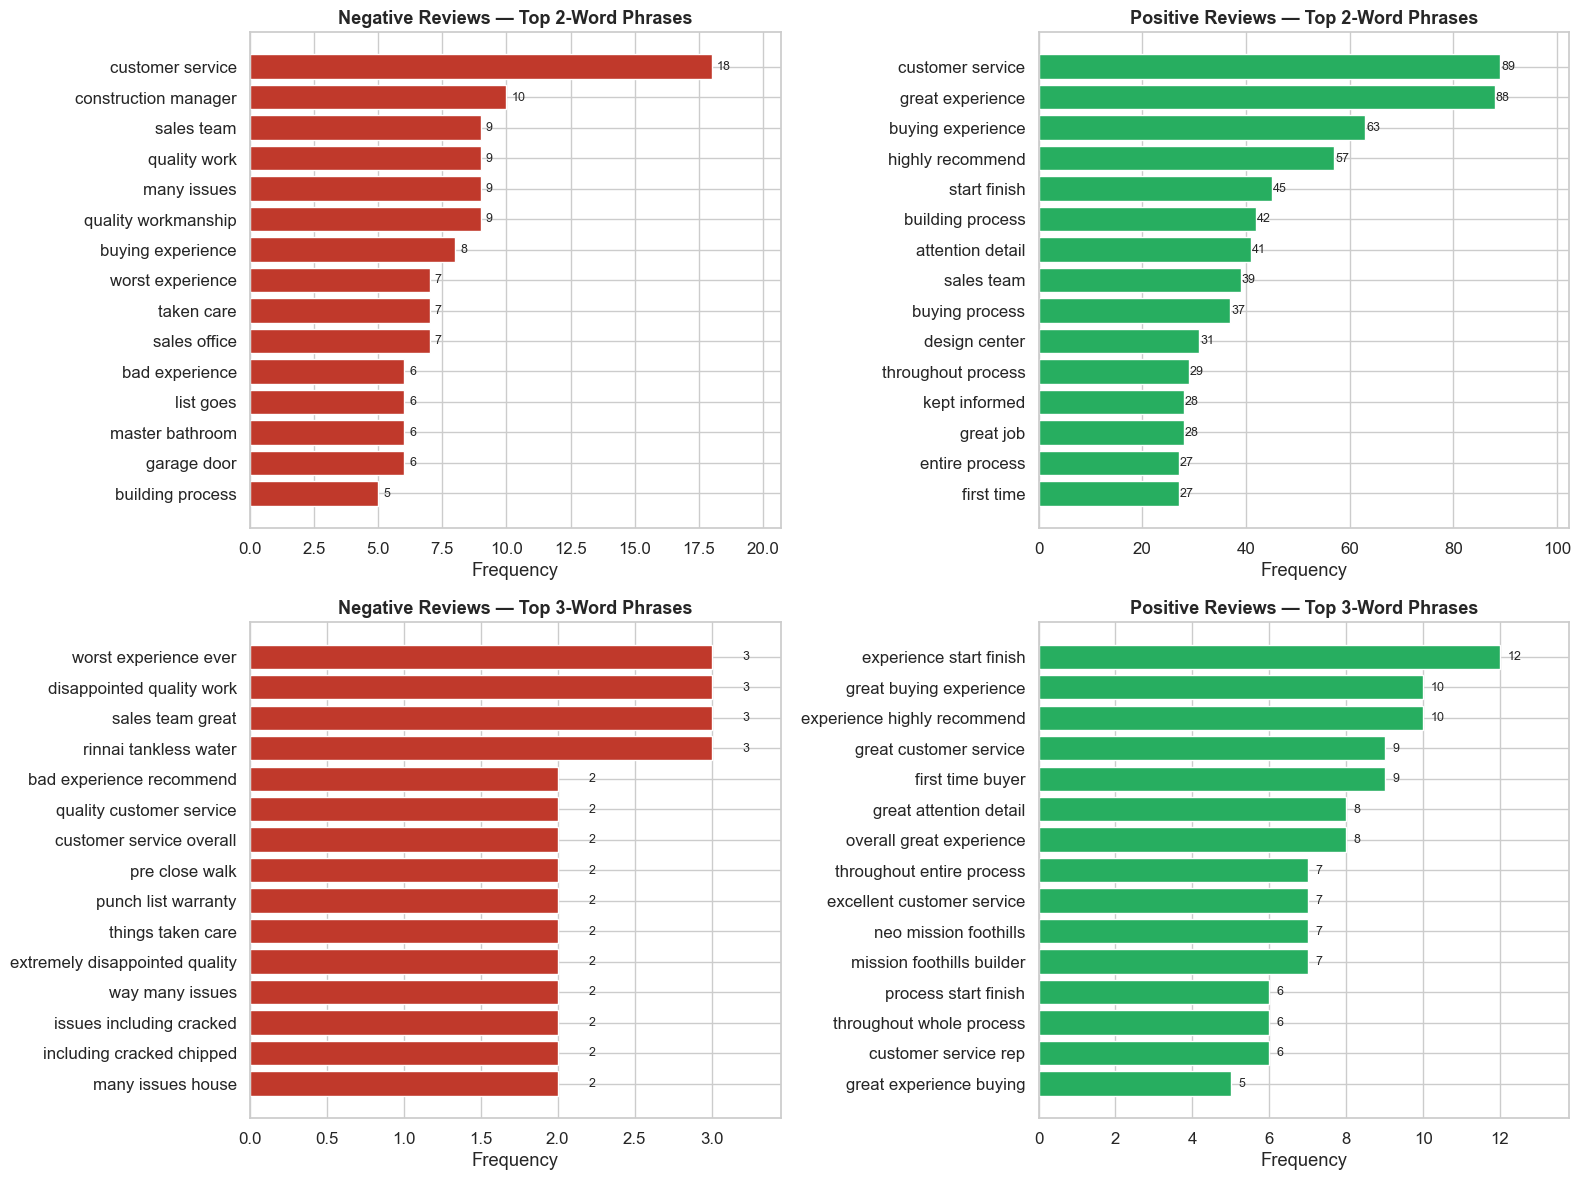

In [25]:
def get_ngrams(texts, n=2, top_k=20):
    """Extract the most common n-word phrases from a collection of texts."""
    all_text = " ".join(texts.astype(str)).lower()
    words = re.findall(r"[a-z']+", all_text)
    words = [w for w in words if w not in stop_words and len(w) > 2]
    ngrams = [" ".join(words[i:i+n]) for i in range(len(words) - n + 1)]
    return Counter(ngrams).most_common(top_k)

neg_texts = df[df["total_score"] <= 2]["review_text"]
pos_texts = df[df["total_score"] == 5]["review_text"]

neg_bigrams = get_ngrams(neg_texts, n=2, top_k=15)
pos_bigrams = get_ngrams(pos_texts, n=2, top_k=15)
neg_trigrams = get_ngrams(neg_texts, n=3, top_k=15)
pos_trigrams = get_ngrams(pos_texts, n=3, top_k=15)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

def plot_ngrams(ax, ngrams, color, title):
    phrases, counts = zip(*ngrams[::-1])
    ax.barh(phrases, counts, color=color, edgecolor="white")
    ax.set_xlim(0, max(counts) * 1.15)
    for i, val in enumerate(counts):
        ax.text(val + 0.2, i, str(val), va="center", fontsize=9)
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel("Frequency")

plot_ngrams(axes[0, 0], neg_bigrams, "#c0392b", "Negative Reviews — Top 2-Word Phrases")
plot_ngrams(axes[0, 1], pos_bigrams, "#27ae60", "Positive Reviews — Top 2-Word Phrases")
plot_ngrams(axes[1, 0], neg_trigrams, "#c0392b", "Negative Reviews — Top 3-Word Phrases")
plot_ngrams(axes[1, 1], pos_trigrams, "#27ae60", "Positive Reviews — Top 3-Word Phrases")

plt.tight_layout()
plt.show()

The negative phrases highlight specific operational pain points. Terms related to customer service, build quality, and warranty support appear frequently in lower-rated reviews, indicating that dissatisfaction often centers around post-purchase issues or construction defects.

In contrast, the most common positive phrases focus on the sales team, the buying experience, and the overall building process. Phrases like “great experience,” “customer service,” and “start to finish” appear frequently in 5-star reviews, suggesting that customers are especially satisfied when the entire homebuying journey feels smooth and well managed from beginning to end.

---
# 5 Predictive AI: Can We Predict Star Ratings From Text?

### The Big Question
If a customer writes a review but hasn't yet clicked a star rating, can ML predict what they'll give based on their words alone?

This is a machine learning classification problem. We train a model on existing reviews (where we know both the text and the rating) and then test whether it can predict the rating on reviews it's never seen before.

### Why This Matters for Business
All of the earlier analysis looked at reviews that already had star ratings attached. This section explores a different question: if we only had the written text of a review, could a algorithm determine whether the customer was satisfied or dissatisfied? This is important because much customer feedback, such as survey comments, emails, support tickets, or social media posts, often comes without a rating. If we can train a model to read text and estimate satisfaction, that approach could be applied to any source of written feedback, even when no numerical score is provided. To test this, I used several machine learning models and evaluated how accurately they could predict star ratings based only on the review text.

### Technical Approach
We build two models:
1. At-Risk Detection (Binary): The most business-useful model. Classifies reviews as "Satisfied" (4-5 Star) or "At-Risk" (1-3 Star). Think of this as a triage system.
2. 3-Class Prediction: A finer-grained model that separates Negative (1-2 Star), Neutral (3 Star), and Positive (4-5 Star).

Important note on class imbalance: 78% of reviews are 4-5 stars. A lazy model could just predict "Positive" every time and claim 78% accuracy. That's useless. So we use balanced class weights (which force the model to pay extra attention to rare negative reviews) and evaluate with Macro F1 Score (which averages performance across all classes equally, so the model can't cheat by ignoring minorities).

In [26]:
# --- Feature Engineering ---
# We give the model more than just raw text. We also provide:
#   - Sentiment score (from VADER) as a numeric feature
#   - Word count (longer reviews tend to be more negative)
#   - Exclamation marks (positive reviews use more!)
# This "hybrid" approach combines text analysis with numeric signals.

from scipy.sparse import hstack, csr_matrix

df["exclamation_count"] = df["review_text"].apply(lambda x: str(x).count("!"))

extra_features = ["vader", "word_count", "exclamation_count"]

def build_hybrid_features(X_texts, X_extras, tfidf_model, fit=False):
    """Combine TF-IDF text features with numeric features into one matrix."""
    if fit:
        text_features = tfidf_model.fit_transform(X_texts)
    else:
        text_features = tfidf_model.transform(X_texts)
    numeric_features = csr_matrix(X_extras.values)
    return hstack([text_features, numeric_features])

print(f"Features for each review:")
print(f"  TF-IDF text features: up to 5,000 word/phrase weights")
print(f"  + VADER sentiment score")
print(f"  + Word count")
print(f"  + Exclamation mark count")
print(f"\nClass distribution in the dataset:")
print(f"  4-5 star (Satisfied): {(df['total_score'] >= 4).sum():>5} ({(df['total_score'] >= 4).mean():.0%})")
print(f"  1-3 star (At-Risk):   {(df['total_score'] <= 3).sum():>5} ({(df['total_score'] <= 3).mean():.0%})")
print(f"\nThis imbalance is why we use balanced class weights.")

Features for each review:
  TF-IDF text features: up to 5,000 word/phrase weights
  + VADER sentiment score
  + Word count
  + Exclamation mark count

Class distribution in the dataset:
  4-5 star (Satisfied):  1590 (78%)
  1-3 star (At-Risk):     449 (22%)

This imbalance is why we use balanced class weights.


## 5.1 At-Risk Customer Detection (Binary Model)

This analysis simplifies the prediction problem into two groups: satisfied customers who gave four or five stars, and at-risk customers who gave one to three stars. The goal is to determine whether the language in a review alone can identify customers who may be dissatisfied.


In [27]:
df["vader"] = df["review_text"].apply(lambda x: sia.polarity_scores(str(x))["compound"])

# --- BINARY MODEL: Satisfied vs At-Risk ---
df["risk_class"] = df["total_score"].apply(
    lambda x: "Satisfied (4-5 Stars)" if x >= 4 else "At-Risk (1-3 Stars)"
)

# split: 80% for training, 20% for testing
# the model NEVER sees the test data during training
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    df[["review_text"] + extra_features],
    df["risk_class"],
    test_size=0.2,
    random_state=42,
    stratify=df["risk_class"],
)

tfidf_b = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), stop_words="english")
X_train_hyb = build_hybrid_features(X_train_b["review_text"].astype(str), X_train_b[extra_features], tfidf_b, fit=True)
X_test_hyb = build_hybrid_features(X_test_b["review_text"].astype(str), X_test_b[extra_features], tfidf_b, fit=False)

# train models with balanced class weights
binary_models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=42, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced", n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=200, random_state=42, max_depth=5),
}

print("Training 3 models on the At-Risk detection task...\n")
print(f"{'Model':<25} {'Accuracy':<12} {'Macro F1':<12} {'At-Risk Recall':<16} {'At-Risk Precision'}")
print("-" * 80)

binary_results = {}
best_b_model = None
best_b_f1 = 0

for name, clf in binary_models.items():
    clf.fit(X_train_hyb, y_train_b)
    y_pred = clf.predict(X_test_hyb)
    
    acc = accuracy_score(y_test_b, y_pred)
    f1 = f1_score(y_test_b, y_pred, average="macro")
    
    report = classification_report(y_test_b, y_pred, output_dict=True, zero_division=0)
    ar_recall = report.get("At-Risk (1-3 Stars)", {}).get("recall", 0)
    ar_prec = report.get("At-Risk (1-3 Stars)", {}).get("precision", 0)
    
    binary_results[name] = {"accuracy": acc, "f1": f1, "predictions": y_pred, "clf": clf}
    print(f"{name:<25} {acc:<12.1%} {f1:<12.3f} {ar_recall:<16.0%} {ar_prec:.0%}")
    
    if f1 > best_b_f1:
        best_b_f1 = f1
        best_b_model = name

print(f"\nBest model: {best_b_model} (Macro F1 = {best_b_f1:.3f})")

Training 3 models on the At-Risk detection task...

Model                     Accuracy     Macro F1     At-Risk Recall   At-Risk Precision
--------------------------------------------------------------------------------
Logistic Regression       81.4%        0.753        72%              56%
Random Forest             82.8%        0.711        43%              67%
Gradient Boosting         84.1%        0.757        58%              66%

Best model: Gradient Boosting (Macro F1 = 0.757)


DETAILED RESULTS: Gradient Boosting
                       precision    recall  f1-score   support

  At-Risk (1-3 Stars)       0.66      0.58      0.62        90
Satisfied (4-5 Stars)       0.88      0.92      0.90       318

             accuracy                           0.84       408
            macro avg       0.77      0.75      0.76       408
         weighted avg       0.83      0.84      0.84       408



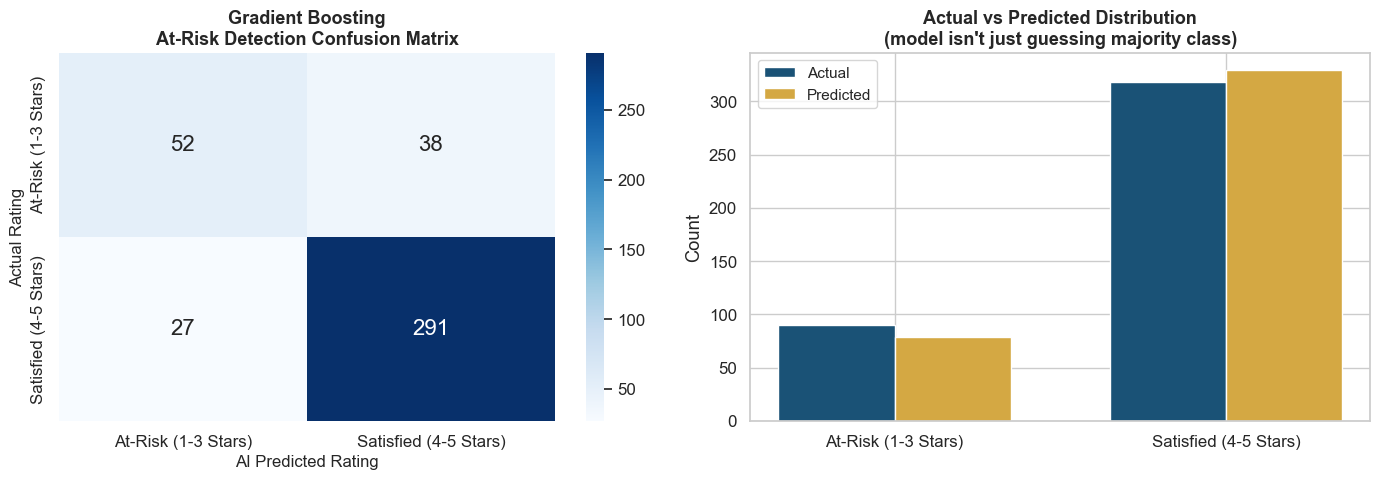

In [28]:
# detailed results + confusion matrix for best binary model
y_pred_b = binary_results[best_b_model]["predictions"]

print(f"DETAILED RESULTS: {best_b_model}")
print("=" * 60)
print(classification_report(y_test_b, y_pred_b, zero_division=0))

labels_b = ["At-Risk (1-3 Stars)", "Satisfied (4-5 Stars)"]
cm_b = confusion_matrix(y_test_b, y_pred_b, labels=labels_b)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# confusion matrix
sns.heatmap(cm_b, annot=True, fmt="d", cmap="Blues", xticklabels=labels_b,
            yticklabels=labels_b, ax=axes[0], annot_kws={"fontsize": 16})
axes[0].set_ylabel("Actual Rating", fontsize=12)
axes[0].set_xlabel("AI Predicted Rating", fontsize=12)
axes[0].set_title(f"{best_b_model}\nAt-Risk Detection Confusion Matrix", fontsize=13, fontweight="bold")

# prediction distribution comparison
actual_counts = pd.Series(y_test_b).value_counts()
pred_counts = pd.Series(y_pred_b).value_counts()
x = np.arange(2)
w = 0.35
axes[1].bar(x - w/2, [actual_counts.get(l, 0) for l in labels_b], w, label="Actual", color=SHEA_BLUE)
axes[1].bar(x + w/2, [pred_counts.get(l, 0) for l in labels_b], w, label="Predicted", color=SHEA_GOLD)
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels_b)
axes[1].set_ylabel("Count")
axes[1].set_title("Actual vs Predicted Distribution\n(model isn't just guessing majority class)", fontsize=13, fontweight="bold")
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()

Gradient Boosting is the most accurate with 84.1% accuracy and the highest Macro F1 (0.757). It catches 58% of at-risk customers from text alone, with 66% precision, meaning when it flags someone as at-risk, it is right 2 out of 3 times. Logistic Regression has better at-risk recall (72%) but more false positives (56% precision). Random Forest is the weakest here because it struggles with the minority class, only catching 43% of at-risk customers despite high overall accuracy. The tradeoff between recall and precision depends on the business use case: if missing an at-risk customer is costly, Logistic Regression's higher recall may be preferable.

## 5.2 Three-Class Prediction (Negative / Neutral / Positive)

This task is more challenging than the previous prediction. Instead of simply identifying satisfied versus at-risk customers, the model must now classify reviews into three groups: negative (1–2 stars), neutral (3 stars), and positive (4–5 stars).

This is significantly harder because 3-star reviews are inherently ambiguous. Customers in this group are often neither strongly satisfied nor strongly dissatisfied, and their language tends to reflect a mix of positive and negative comments.

In [29]:
# --- 3-CLASS MODEL ---
def rating_bucket(score):
    if score <= 2:
        return "Negative (1-2 Stars)"
    elif score == 3:
        return "Neutral (3 Stars)"
    else:
        return "Positive (4-5 Stars)"

df["rating_class"] = df["total_score"].apply(rating_bucket)

X_train_3, X_test_3, y_train_3, y_test_3 = train_test_split(
    df[["review_text"] + extra_features],
    df["rating_class"],
    test_size=0.2,
    random_state=42,
    stratify=df["rating_class"],
)

tfidf_3 = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), stop_words="english")
X_train_3h = build_hybrid_features(X_train_3["review_text"].astype(str), X_train_3[extra_features], tfidf_3, fit=True)
X_test_3h = build_hybrid_features(X_test_3["review_text"].astype(str), X_test_3[extra_features], tfidf_3, fit=False)

three_class_models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=42, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced", n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=200, random_state=42, max_depth=5),
}

print("Training 3 models on the 3-class task...\n")
print(f"{'Model':<25} {'Accuracy':<12} {'Macro F1':<12} {'Neg Recall':<13} {'Neu Recall':<13} {'Pos Recall'}")
print("-" * 85)

three_results = {}
best_3_model = None
best_3_f1 = 0

for name, clf in three_class_models.items():
    clf.fit(X_train_3h, y_train_3)
    y_pred = clf.predict(X_test_3h)
    
    acc = accuracy_score(y_test_3, y_pred)
    f1 = f1_score(y_test_3, y_pred, average="macro")
    report = classification_report(y_test_3, y_pred, output_dict=True, zero_division=0)
    
    neg_r = report.get("Negative (1-2 Stars)", {}).get("recall", 0)
    neu_r = report.get("Neutral (3 Stars)", {}).get("recall", 0)
    pos_r = report.get("Positive (4-5 Stars)", {}).get("recall", 0)
    
    three_results[name] = {"accuracy": acc, "f1": f1, "predictions": y_pred}
    print(f"{name:<25} {acc:<12.1%} {f1:<12.3f} {neg_r:<13.0%} {neu_r:<13.0%} {pos_r:.0%}")
    
    if f1 > best_3_f1:
        best_3_f1 = f1
        best_3_model = name

print(f"\nBest 3-class model: {best_3_model} (Macro F1 = {best_3_f1:.3f})")

Training 3 models on the 3-class task...

Model                     Accuracy     Macro F1     Neg Recall    Neu Recall    Pos Recall
-------------------------------------------------------------------------------------
Logistic Regression       76.2%        0.561        58%           37%           85%
Random Forest             77.5%        0.319        3%            2%            99%
Gradient Boosting         79.2%        0.510        39%           15%           94%

Best 3-class model: Logistic Regression (Macro F1 = 0.561)



DETAILED RESULTS: Logistic Regression
                      precision    recall  f1-score   support

Negative (1-2 Stars)       0.34      0.58      0.43        38
   Neutral (3 Stars)       0.37      0.37      0.37        52
Positive (4-5 Stars)       0.92      0.85      0.89       318

            accuracy                           0.76       408
           macro avg       0.54      0.60      0.56       408
        weighted avg       0.80      0.76      0.78       408



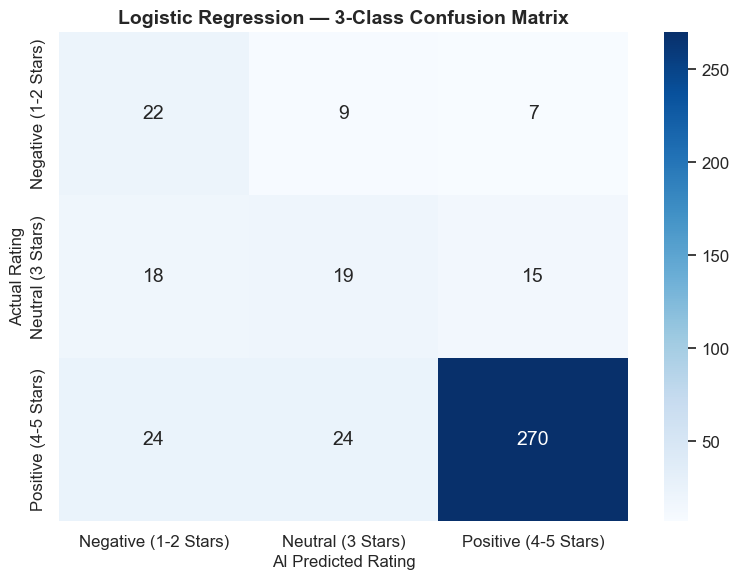

In [30]:
# 3-class confusion matrix
y_pred_3 = three_results[best_3_model]["predictions"]

print(f"\nDETAILED RESULTS: {best_3_model}")
print("=" * 60)
print(classification_report(y_test_3, y_pred_3, zero_division=0))

labels_3 = ["Negative (1-2 Stars)", "Neutral (3 Stars)", "Positive (4-5 Stars)"]
cm_3 = confusion_matrix(y_test_3, y_pred_3, labels=labels_3)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_3, annot=True, fmt="d", cmap="Blues", xticklabels=labels_3,
            yticklabels=labels_3, ax=ax, annot_kws={"fontsize": 14})
ax.set_ylabel("Actual Rating", fontsize=12)
ax.set_xlabel("AI Predicted Rating", fontsize=12)
ax.set_title(f"{best_3_model} — 3-Class Confusion Matrix", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.savefig("3class_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

These results show why overall accuracy alone is not sufficient for evaluating model performance. Gradient Boosting achieved the highest overall accuracy at 79.2%, but looking at the recall by class reveals important differences between the models. Random Forest performed poorly at identifying negative and neutral reviews, capturing only 3% of negative reviews and 2% of neutral reviews. In practice, it was largely predicting most reviews as positive and benefiting from the fact that positive reviews dominate the dataset. Logistic Regression provided the most balanced performance, correctly identifying 58% of negative reviews and 37% of neutral reviews, making it more useful for detecting dissatisfied customers. The key takeaway is that while predicting customer sentiment from text is feasible, neutral reviews remain the most difficult category to classify, since the language in 3-star reviews often contains a genuine mix of positive and negative signals.

## 5.3 Most Predictive Words by Category

When the prediction model evaluates a review, certain words influence its decision more than others. This section highlights the words that had the strongest impact on predicting each rating category. In simple terms, this analysis asks: which words most strongly signal that a review is negative, neutral, or positive? Longer bars indicate that a word had a stronger influence on the model’s prediction.

In [31]:
# what words are most predictive of each class?
lr_3 = three_class_models["Logistic Regression"]
feature_names = np.array(list(tfidf_3.get_feature_names_out()) + extra_features)

print("=" * 70)
print("MOST PREDICTIVE WORDS FOR EACH RATING CATEGORY")
print("These are the words/features that most strongly signal each class.")
print("=" * 70)

for i, label in enumerate(lr_3.classes_):
    top_idx = lr_3.coef_[i].argsort()[-12:][::-1]
    bottom_idx = lr_3.coef_[i].argsort()[:5]
    
    print(f"\n  {label}:")
    print(f"    {'Strongest positive signals:':<35}")
    for j in top_idx:
        word = feature_names[j]
        coef = lr_3.coef_[i][j]
        bar = "█" * int(abs(coef) * 4)
        print(f"      {word:<30} {bar} ({coef:+.3f})")

MOST PREDICTIVE WORDS FOR EACH RATING CATEGORY
These are the words/features that most strongly signal each class.

  Negative (1-2 Stars):
    Strongest positive signals:        
      don                            █████ (+1.291)
      workmanship average            █████ (+1.272)
      beware                         ████ (+1.231)
      care                           ████ (+1.225)
      repairs                        ████ (+1.163)
      shea                           ████ (+1.136)
      outstanding experience         ████ (+1.041)
      bad                            ████ (+1.032)
      months                         ████ (+1.031)
      outstanding                    ███ (+0.956)
      appliances                     ███ (+0.941)
      average                        ███ (+0.929)

  Neutral (3 Stars):
    Strongest positive signals:        
      hoa                            █████ (+1.356)
      unfortunately                  ████ (+1.199)
      trust                          ████ (+1

The predictive words tell a story that aligns with everything else in this analysis. Negative signals are concrete and specific: 'repairs,' 'months,' 'appliances,' 'workmanship average.' Neutral reviews use hedging language: 'unfortunately,' 'lacking,' 'nice home' (faint praise), and 'better' (implying something could be improved). Positive signals are emotional and relational: 'excellent,' 'professional,' 'helpful,' 'team,' 'awesome.' Note that 'vader' appears as the strongest positive predictor because the VADER sentiment score was included as a numeric feature, and it strongly correlates with positive ratings.

---
# 6. Large Language Model Analysis (LLaMA 3.2 via Ollama)

### What is a Large Language Model?

Everything above used specialized tools, each designed to do one narrow task (score sentiment, classify topics, predict ratings). A LLM like Meta's LLaMA 3.2 is different. It's a general-purpose AI that can:

- Read and understand a review the way a human would
- Follow complex instructions ("categorize this review, extract action items, and draft a response")
- Produce natural language output, not just numbers

In [32]:
import ollama
import time
from tqdm import tqdm

def llm_response(prompt, model="llama3.2", system_prompt="You are a helpful assistant."):
    """Send a prompt to the local LLM and return its response."""
    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user",   "content": prompt},
    ]
    response = ollama.chat(model=model, messages=messages)
    return response["message"]["content"]

# quick test
print("Testing connection to LLaMA 3.2...")
test = llm_response("In one sentence, what is sentiment analysis?")
print(f"LLM response: {test}")
print("\nConnection successful!")

Testing connection to LLaMA 3.2...
LLM response: Sentiment analysis is a natural language processing technique used to automatically determine the emotional tone or sentiment behind a piece of text, such as a review, social media post, or customer feedback, to help organizations understand public opinion and make informed decisions.

Connection successful!


## 6.1 Zero-Shot Sentiment Classification

**Zero-shot** means we give the LLM absolutely no examples. We just say: *"Is this review positive or negative?"* and it figures it out from its pre-trained understanding of language.

We'll run this on a stratified sample of 50 reviews (to keep runtime reasonable) and compare the LLM's accuracy against VADER.

In [33]:
# --- ZERO-SHOT CLASSIFICATION ---
# sample 50 reviews: 25 positive (4-5 Stars) and 25 negative/neutral (1-3 Stars)
pos_sample = df[df["total_score"] >= 4].sample(25, random_state=42)
neg_sample = df[df["total_score"] <= 3].sample(25, random_state=42)
sample = pd.concat([pos_sample, neg_sample]).sample(frac=1, random_state=42).reset_index(drop=True)
sample["true_label"] = sample["total_score"].apply(lambda x: "POSITIVE" if x >= 4 else "NEGATIVE")

def zero_shot_prompt(review_text):
    return (
        "Classify the sentiment of the following home builder review as either "
        "POSITIVE or NEGATIVE. Respond with ONLY one word: POSITIVE or NEGATIVE.\n\n"
        f"Review: {review_text}\n\n"
        "Sentiment:"
    )

def parse_sentiment_label(response_text):
    """Parse LLM output to a clean label."""
    text = response_text.strip().lower()
    if "positive" in text:
        return "POSITIVE"
    elif "negative" in text:
        return "NEGATIVE"
    return "POSITIVE"  # default if ambiguous

# run zero-shot on the sample
print("Running zero-shot classification on 50 reviews with LLaMA 3.2...")
zero_shot_preds = []
zero_shot_raw = []

for review in tqdm(sample["review_text"], desc="Zero-Shot"):
    prompt = zero_shot_prompt(str(review)[:500])  # truncate very long reviews
    response = llm_response(prompt)
    zero_shot_raw.append(response)
    zero_shot_preds.append(parse_sentiment_label(response))

sample["zs_pred"] = zero_shot_preds
sample["zs_raw"] = zero_shot_raw

# also get VADER predictions for the same sample
sample["vader_score"] = sample["review_text"].apply(lambda x: sia.polarity_scores(str(x))["compound"])
sample["vader_pred"] = sample["vader_score"].apply(lambda x: "POSITIVE" if x >= 0.05 else "NEGATIVE")

# compare
zs_acc = (sample["zs_pred"] == sample["true_label"]).mean()
vader_acc = (sample["vader_pred"] == sample["true_label"]).mean()

print(f"\n{'='*55}")
print(f"  ZERO-SHOT RESULTS (50 reviews)")
print(f"{'='*55}")
print(f"  {'Method':<25} {'Accuracy':<15}")
print(f"  {'-'*40}")
print(f"  {'LLaMA 3.2 (Zero-Shot)':<25} {zs_acc:<15.1%}")
print(f"  {'VADER':<25} {vader_acc:<15.1%}")
print(f"{'='*55}")

Running zero-shot classification on 50 reviews with LLaMA 3.2...


Zero-Shot: 100%|██████████| 50/50 [05:05<00:00,  6.11s/it]



  ZERO-SHOT RESULTS (50 reviews)
  Method                    Accuracy       
  ----------------------------------------
  LLaMA 3.2 (Zero-Shot)     76.0%          
  VADER                     68.0%          


## 6.2 Few-Shot At-Risk Detection

**Few-shot** means we give the LLM a few labeled examples before asking it to classify. This is like training a new employee by showing them: *"Here's what a happy customer sounds like. Here's what an unhappy one sounds like. Now you classify the rest."*

We'll give it 2 positive and 2 negative examples, then test on the same 50 reviews.

In [34]:
# --- FEW-SHOT CLASSIFICATION ---
# select demonstration examples (NOT from the test sample)
test_indices = set(sample.index)

# pick 2 clear positive and 2 clear negative reviews as examples
pos_pool = df[(df["total_score"] == 5) & (~df.index.isin(test_indices))]
neg_pool = df[(df["total_score"] == 1) & (~df.index.isin(test_indices))]

fs_pos_examples = pos_pool.sample(2, random_state=7)["review_text"].tolist()
fs_neg_examples = neg_pool.sample(2, random_state=7)["review_text"].tolist()

print("Few-shot examples selected:\n")
for i, ex in enumerate(fs_pos_examples):
    print(f"  POSITIVE example {i+1}: \"{str(ex)[:120]}...\"")
for i, ex in enumerate(fs_neg_examples):
    print(f"  NEGATIVE example {i+1}: \"{str(ex)[:120]}...\"")

def few_shot_prompt(review_text):
    return (
        "Classify this home builder review as POSITIVE or NEGATIVE.\n"
        "Respond with ONLY one word: POSITIVE or NEGATIVE.\n\n"
        "--- Examples ---\n"
        f"Review: {str(fs_pos_examples[0])[:300]}\n"
        "Sentiment: POSITIVE\n\n"
        f"Review: {str(fs_neg_examples[0])[:300]}\n"
        "Sentiment: NEGATIVE\n\n"
        f"Review: {str(fs_pos_examples[1])[:300]}\n"
        "Sentiment: POSITIVE\n\n"
        f"Review: {str(fs_neg_examples[1])[:300]}\n"
        "Sentiment: NEGATIVE\n\n"
        "--- Now classify this review ---\n"
        f"Review: {review_text}\n\n"
        "Sentiment:"
    )

# run few-shot
print("\nRunning few-shot classification on 50 reviews with LLaMA 3.2...")
fs_preds = []
fs_raw = []

for review in tqdm(sample["review_text"], desc="Few-Shot"):
    prompt = few_shot_prompt(str(review)[:500])
    response = llm_response(prompt)
    fs_raw.append(response)
    fs_preds.append(parse_sentiment_label(response))

sample["fs_pred"] = fs_preds
sample["fs_raw"] = fs_raw
fs_acc = (sample["fs_pred"] == sample["true_label"]).mean()

print(f"\n{'='*60}")
print(f"  COMPARISON: VADER vs Zero-Shot vs Few-Shot")
print(f"{'='*60}")
print(f"  {'Method':<30} {'Accuracy':<15}")
print(f"  {'-'*45}")
print(f"  {'VADER (rule-based)':<30} {vader_acc:<15.1%}")
print(f"  {'LLaMA 3.2 Zero-Shot':<30} {zs_acc:<15.1%}")
print(f"  {'LLaMA 3.2 Few-Shot':<30} {fs_acc:<15.1%}")
print(f"{'='*60}")

Few-shot examples selected:

  POSITIVE example 1: "Carolyn and Dan have been right on top of questions and problems..."
  POSITIVE example 2: "Great experience- people are responsive and communicate effectively...."
  NEGATIVE example 1: "I had a really bad experience with Shea. I was given the wrong information since the beginning, and just went downhill f..."
  NEGATIVE example 2: "A bunch of stuff wrong with the house and I can't get anything fixed...."

Running few-shot classification on 50 reviews with LLaMA 3.2...


Few-Shot: 100%|██████████| 50/50 [05:24<00:00,  6.49s/it]



  COMPARISON: VADER vs Zero-Shot vs Few-Shot
  Method                         Accuracy       
  ---------------------------------------------
  VADER (rule-based)             68.0%          
  LLaMA 3.2 Zero-Shot            76.0%          
  LLaMA 3.2 Few-Shot             76.0%          


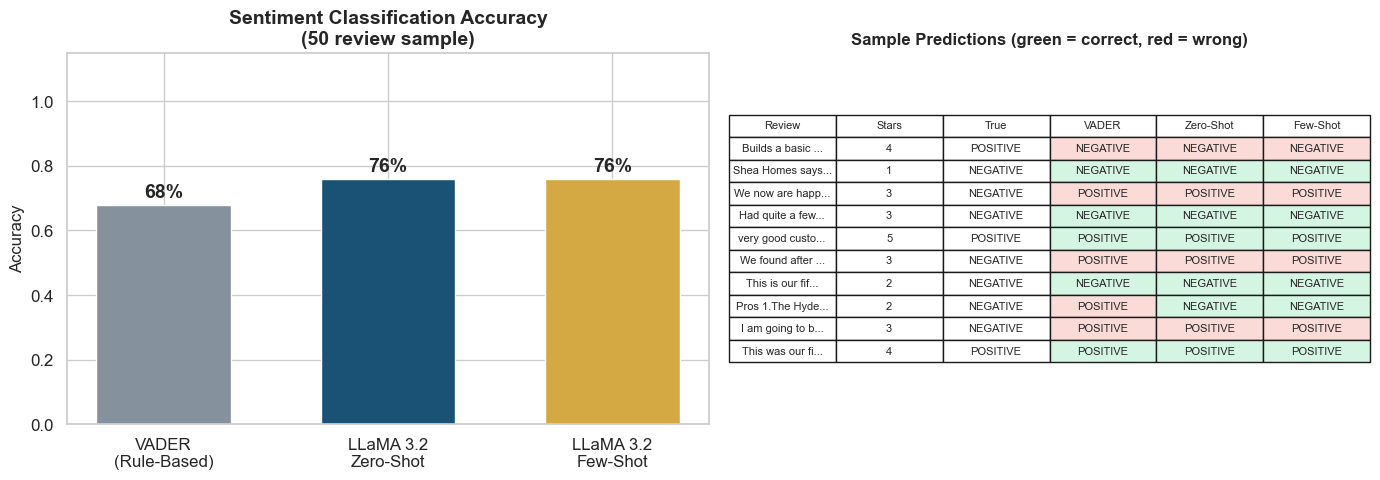

In [35]:
# visualize the comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# left: accuracy comparison
methods = ["VADER\n(Rule-Based)", "LLaMA 3.2\nZero-Shot", "LLaMA 3.2\nFew-Shot"]
accuracies = [vader_acc, zs_acc, fs_acc]
colors = ["#85929e", SHEA_BLUE, SHEA_GOLD]
bars = axes[0].bar(methods, accuracies, color=colors, edgecolor="white", width=0.6)
for bar, acc in zip(bars, accuracies):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f"{acc:.0%}", ha="center", va="bottom", fontsize=14, fontweight="bold")
axes[0].set_ylim(0, 1.15)
axes[0].set_ylabel("Accuracy", fontsize=12)
axes[0].set_title("Sentiment Classification Accuracy\n(50 review sample)", fontsize=14, fontweight="bold")

# right: sample predictions table
display_cols = sample[["review_text", "total_score", "true_label", "vader_pred", "zs_pred", "fs_pred"]].head(10).copy()
display_cols["review_text"] = display_cols["review_text"].apply(lambda x: str(x)[:15] + "...")
display_cols.columns = ["Review", "Stars", "True", "VADER", "Zero-Shot", "Few-Shot"]

# build a text table on the right axis
axes[1].axis("off")
table = axes[1].table(
    cellText=display_cols.values,
    colLabels=display_cols.columns,
    cellLoc="center",
    loc="center",
)
table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1, 1.4)

# color code: green if correct, red if wrong
for i in range(len(display_cols)):
    true_label = display_cols.iloc[i]["True"]
    for j, col in enumerate(["VADER", "Zero-Shot", "Few-Shot"]):
        pred = display_cols.iloc[i][col]
        color = "#d5f5e3" if pred == true_label else "#fadbd8"
        table[i + 1, j + 3].set_facecolor(color)

axes[1].set_title("Sample Predictions (green = correct, red = wrong)", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.savefig("llm_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 6.3 Deep Review Intelligence

This is where the LLM truly separates itself from traditional NLP tools. Instead of just outputting "positive" or "negative," we ask it to read the review like a business analyst and produce a structured intelligence report.

In [36]:
ANALYST_SYSTEM_PROMPT = (
    "You are a customer experience analyst at Shea Homes, a major home builder. "
    "You analyze customer reviews to extract actionable business intelligence. "
    "Be specific, concise, and business-focused."
)

def deep_review_prompt(review_text, star_rating, location):
    return (
        f"Analyze this verified homebuyer review for Shea Homes.\n\n"
        f"RATING: {star_rating}/5 stars\n"
        f"LOCATION: {location}\n"
        f"REVIEW: \"{review_text}\"\n\n"
        f"Provide your analysis in this EXACT format:\n\n"
        f"CATEGORY: [Sales Experience | Construction Quality | Warranty & Service | "
        f"Communication | Design & Features | Value & Pricing | General Praise | Multiple Issues]\n"
        f"SENTIMENT: [Positive | Negative | Mixed]\n"
        f"KEY THEMES: [2-4 specific themes]\n"
        f"ACTION ITEMS: [1-3 specific, actionable next steps for the Shea team]\n"
        f"URGENCY: [Low | Medium | High | Critical]\n"
    )

# select diverse reviews to demo
demo_reviews = pd.concat([
    df[df["total_score"] == 1].sample(1, random_state=10),
    df[df["total_score"] == 2].sample(1, random_state=5),
    df[df["total_score"] == 5].sample(1, random_state=20),
])


for _, row in demo_reviews.iterrows():
    print("=" * 70)
    text = str(row["review_text"])
    print(f"REVIEW INPUT: {row['total_score']}Stars | {row['location']}")
    print(f'"{text[:400]}{"..." if len(text) > 400 else ""}"')
    
    prompt = deep_review_prompt(text[:600], row["total_score"], row["location"])
    analysis = llm_response(prompt, system_prompt=ANALYST_SYSTEM_PROMPT)
    
    print(f"\nLLaMA 3.2 ANALYSIS:")
    print(analysis)
    print()

REVIEW INPUT: 1Stars | Denver, NC
"Because this review is going on a public website, I am limiting the review to a summary statement. Overall, the buying experience was poor, which is a shame because as the home buying market shifts and there are fewer buyers, customer service will be the key to future sales."

LLaMA 3.2 ANALYSIS:
Here is the analysis of the review in the exact format requested:

CATEGORY: Value & Pricing
SENTIMENT: Negative
KEY THEMES: 
1. Inadequate customer service during a competitive home buying market
2. Perception of poor value for the price paid

ACTION ITEMS:
1. Conduct a market analysis to identify and address pricing gaps to improve competitiveness and perceived value.
2. Review and adjust customer service protocols to ensure timely and effective issue resolution, especially during periods of increased demand.
3. Gather feedback from other homebuyers to identify and address any systemic issues that may be contributing to negative reviews.

URGENCY: Low

REVI

## 6.4 AI-Generated Executive Briefing

In [38]:
# compile the 20 most recent reviews into a briefing
recent = df.nlargest(20, "date")

review_block = "\n".join([
    f"- [{row['total_score']} Stars, {row['location']}] {str(row['review_text'])[:200]}"
    for _, row in recent.iterrows()
])

briefing_prompt = (
    f"Below are {len(recent)} recent customer reviews for Shea Homes.\n"
    f"Write a concise EXECUTIVE BRIEFING for a director who has 2 minutes to read it.\n\n"
    f"REVIEWS:\n{review_block}\n\n"
    f"Format your briefing as:\n"
    f"1. OVERALL PULSE: One sentence on general customer sentiment\n"
    f"2. TOP POSITIVES: 2-3 things customers love most, with evidence\n"
    f"3. TOP CONCERNS: 2-3 most common complaints, with evidence\n"
    f"4. REGIONAL NOTES: Any patterns by location\n"
    f"5. RECOMMENDED ACTIONS: 3 specific, prioritized next steps\n\n"
    f"Be direct and actionable. No fluff."
)

print("=" * 70)
print("AI-GENERATED EXECUTIVE BRIEFING")
print(f"Based on the 20 most recent reviews")
print(f"({recent['date'].min().strftime('%b %Y')} to {recent['date'].max().strftime('%b %Y')})")
print("=" * 70)

briefing = llm_response(briefing_prompt, system_prompt=ANALYST_SYSTEM_PROMPT)
print(briefing)

AI-GENERATED EXECUTIVE BRIEFING
Based on the 20 most recent reviews
(Feb 2026 to Mar 2026)
**EXECUTIVE BRIEFING**

**OVERALL PULSE:** Overall, customers are extremely satisfied with their experience with Shea Homes, with 70% of reviews receiving 5-star ratings, but with some notable concerns regarding quality and customer service.

**TOP POSITIVES:**

* **Excellent Customer Service:** Customers consistently praise the sales team, site supervisors, and customer service representatives for their professionalism, kindness, and responsiveness.
* **Well-Designed Homes:** Many customers express satisfaction with the design and layout of their new homes, with some even mentioning that it exceeded their expectations.
* **Positive Communication:** Customers appreciate the clear and transparent communication throughout the buying process, from initial contact to move-in.

**TOP CONCERNS:**

* **Quality and Construction:** Several customers express concerns about the quality of finishes, construc